# Vergleichende Analyse der Prompt-Ansätze (Zero-Shot vs. Few-Shot vs. Two-Stage)

Diese Analyse vergleicht die drei getesteten Prompt-Engineering-Architekturen (**Zero-Shot**, **Few-Shot**, **Two-Stage**) systematisch über alle klinischen Handlungsfelder sowohl für **Lohmann & Rauscher (2 Experten Konsens)**, für den **NursIT Experten (Experte 3)** als auch in einer **Gesamtschau über alle 3 Experten zusammen** für die Wundbeschreibung und den Primärverband auf Ebene 3 (Verbandsklassen-Ebene).

### Gruppierte Hauptkategorien:
1. **Wundbeschreibung:** Aggregierter Mittelwert aus 7 Kernmerkmals-Kategorien:
   - `Wundtyp` (Exakter Match)
   - `Lokalisation` (Exakter Match)
   - `Exsudatmenge` (Ordinal-Score)
   - `Infektionsstatus` (Set F1)
   - `Wundstadium` (Set F1)
   - `Wundrand` (Set F1)
   - `Wundumgebung` (Set F1)
2. **Debridement Methode:** Methodische Auswahl (mechanisch, enzymatisch, autolytisch etc.)
3. **Primärverband (Level 2):** Produktfamilien-Ebene (18 Produktgruppen, z.B. Suprasorb A, Suprasorb P, Vliwasorb)
4. **Sekundärverband:** Ergänzende Produkte & Fixierung
5. **Kompressionsprodukt:** Produktwahl bei Kompressionstherapie

In [1]:
import os, sys, pandas as pd, numpy as np, matplotlib.pyplot as plt, seaborn as sns
sys.path.insert(0, ".")
sys.path.insert(0, "notebooks/analyse_categories")

from master_heatmap import build_master_heatmap_dataframe
from primaerverband_calc import calculate_primaerverband_lr_scores, calculate_primaerverband_nursit_scores, calculate_3_expert_inter_rater_level3

df_master = build_master_heatmap_dataframe()
print("Master-Datenbank erfolgreich geladen.")

Master-Datenbank erfolgreich geladen.


## 1. Detaillierter Vergleich: Wundbeschreibung (7 Einzelkategorien)

Vergleich der Leistungsfähigkeit der drei Prompt-Ansätze bei den 7 Einzelkategorien der Wundbeschreibung für **Lohmann & Rauscher** sowie für den **NursIT Experten**.

=== WUNDBESCHREIBUNG: LOHMANN & RAUSCHER (2 EXPERTEN) ===


,Zero-Shot,Few-Shot,Two-Stage,FS vs ZS (Δ),2S vs ZS (Δ),2S vs FS (Δ)
Wundtyp,48.3,65.0,63.3,16.7,15.0,-1.7
Lokalisation,85.0,89.7,85.0,4.7,0.0,-4.7
Exsudatmenge,91.8,89.1,90.5,-2.7,-1.3,1.4
Infektionsstatus,96.7,93.1,95.0,-3.6,-1.7,1.9
Wundstadium,73.9,77.6,77.2,3.7,3.3,-0.4
Wundrand,70.2,70.6,67.0,0.4,-3.2,-3.6
Wundumgebung,67.9,59.5,58.4,-8.5,-9.6,-1.1


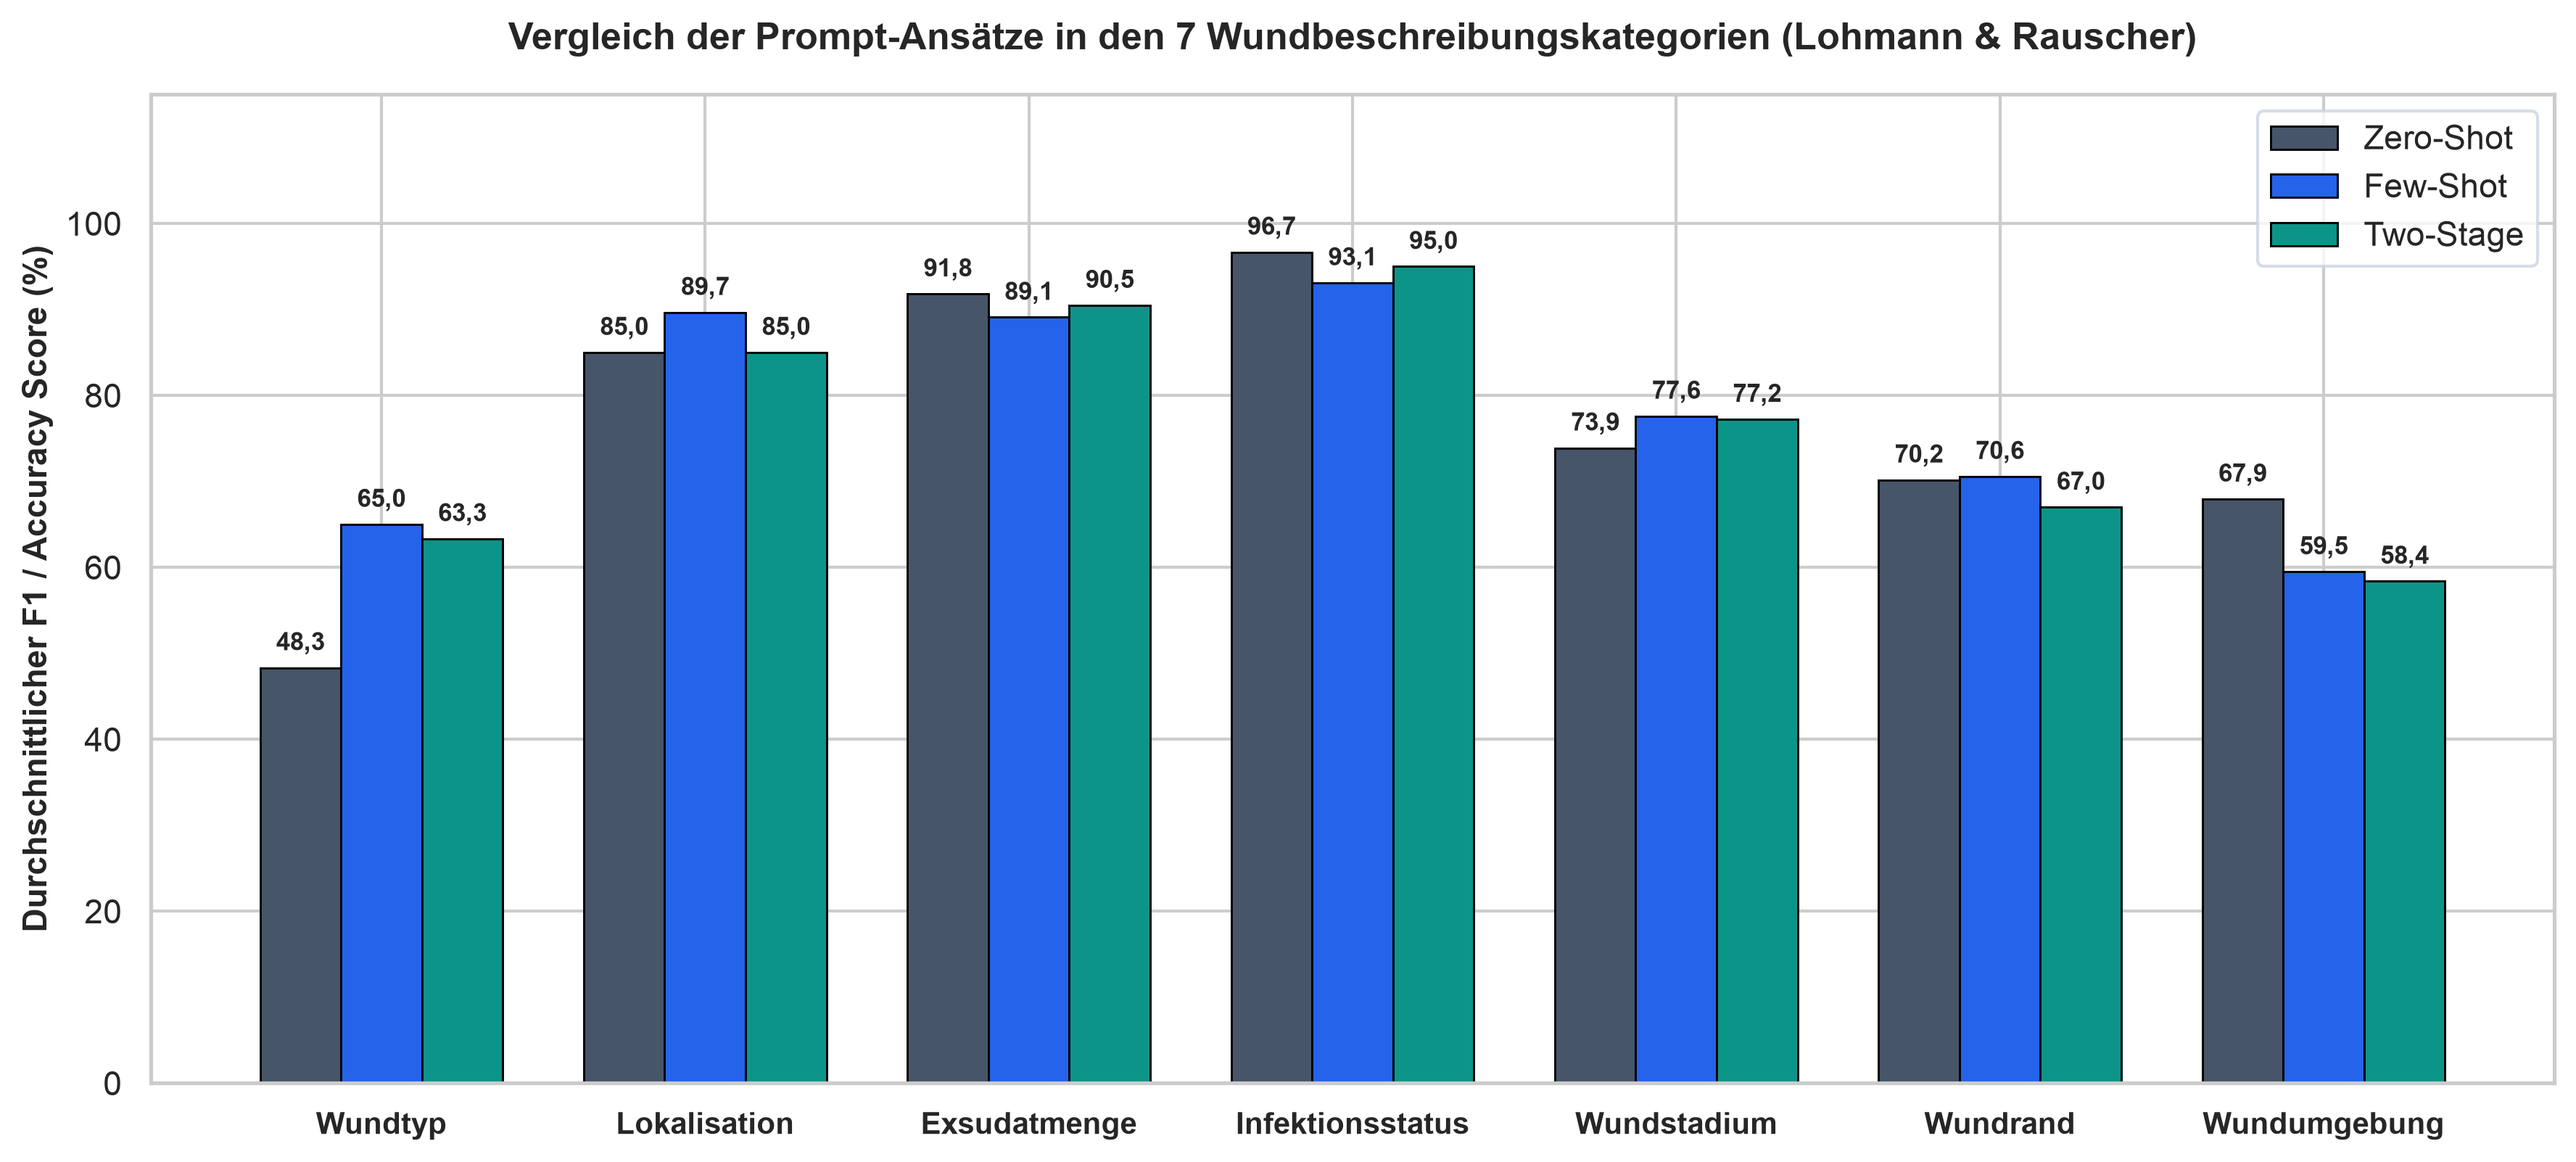


=== WUNDBESCHREIBUNG: NURSIT (EXPERTE 3) ===


,Zero-Shot,Few-Shot,Two-Stage,FS vs ZS (Δ),2S vs ZS (Δ),2S vs FS (Δ)
Wundtyp,41.7,40.0,45.0,-1.7,3.3,5.0
Lokalisation,81.7,82.8,78.3,1.1,-3.3,-4.4
Exsudatmenge,84.4,85.6,85.0,1.2,0.6,-0.6
Infektionsstatus,82.5,83.6,84.2,1.1,1.7,0.5
Wundstadium,77.6,76.2,76.1,-1.4,-1.6,-0.2
Wundrand,69.5,66.0,64.2,-3.5,-5.3,-1.8
Wundumgebung,47.9,49.4,51.7,1.5,3.7,2.2


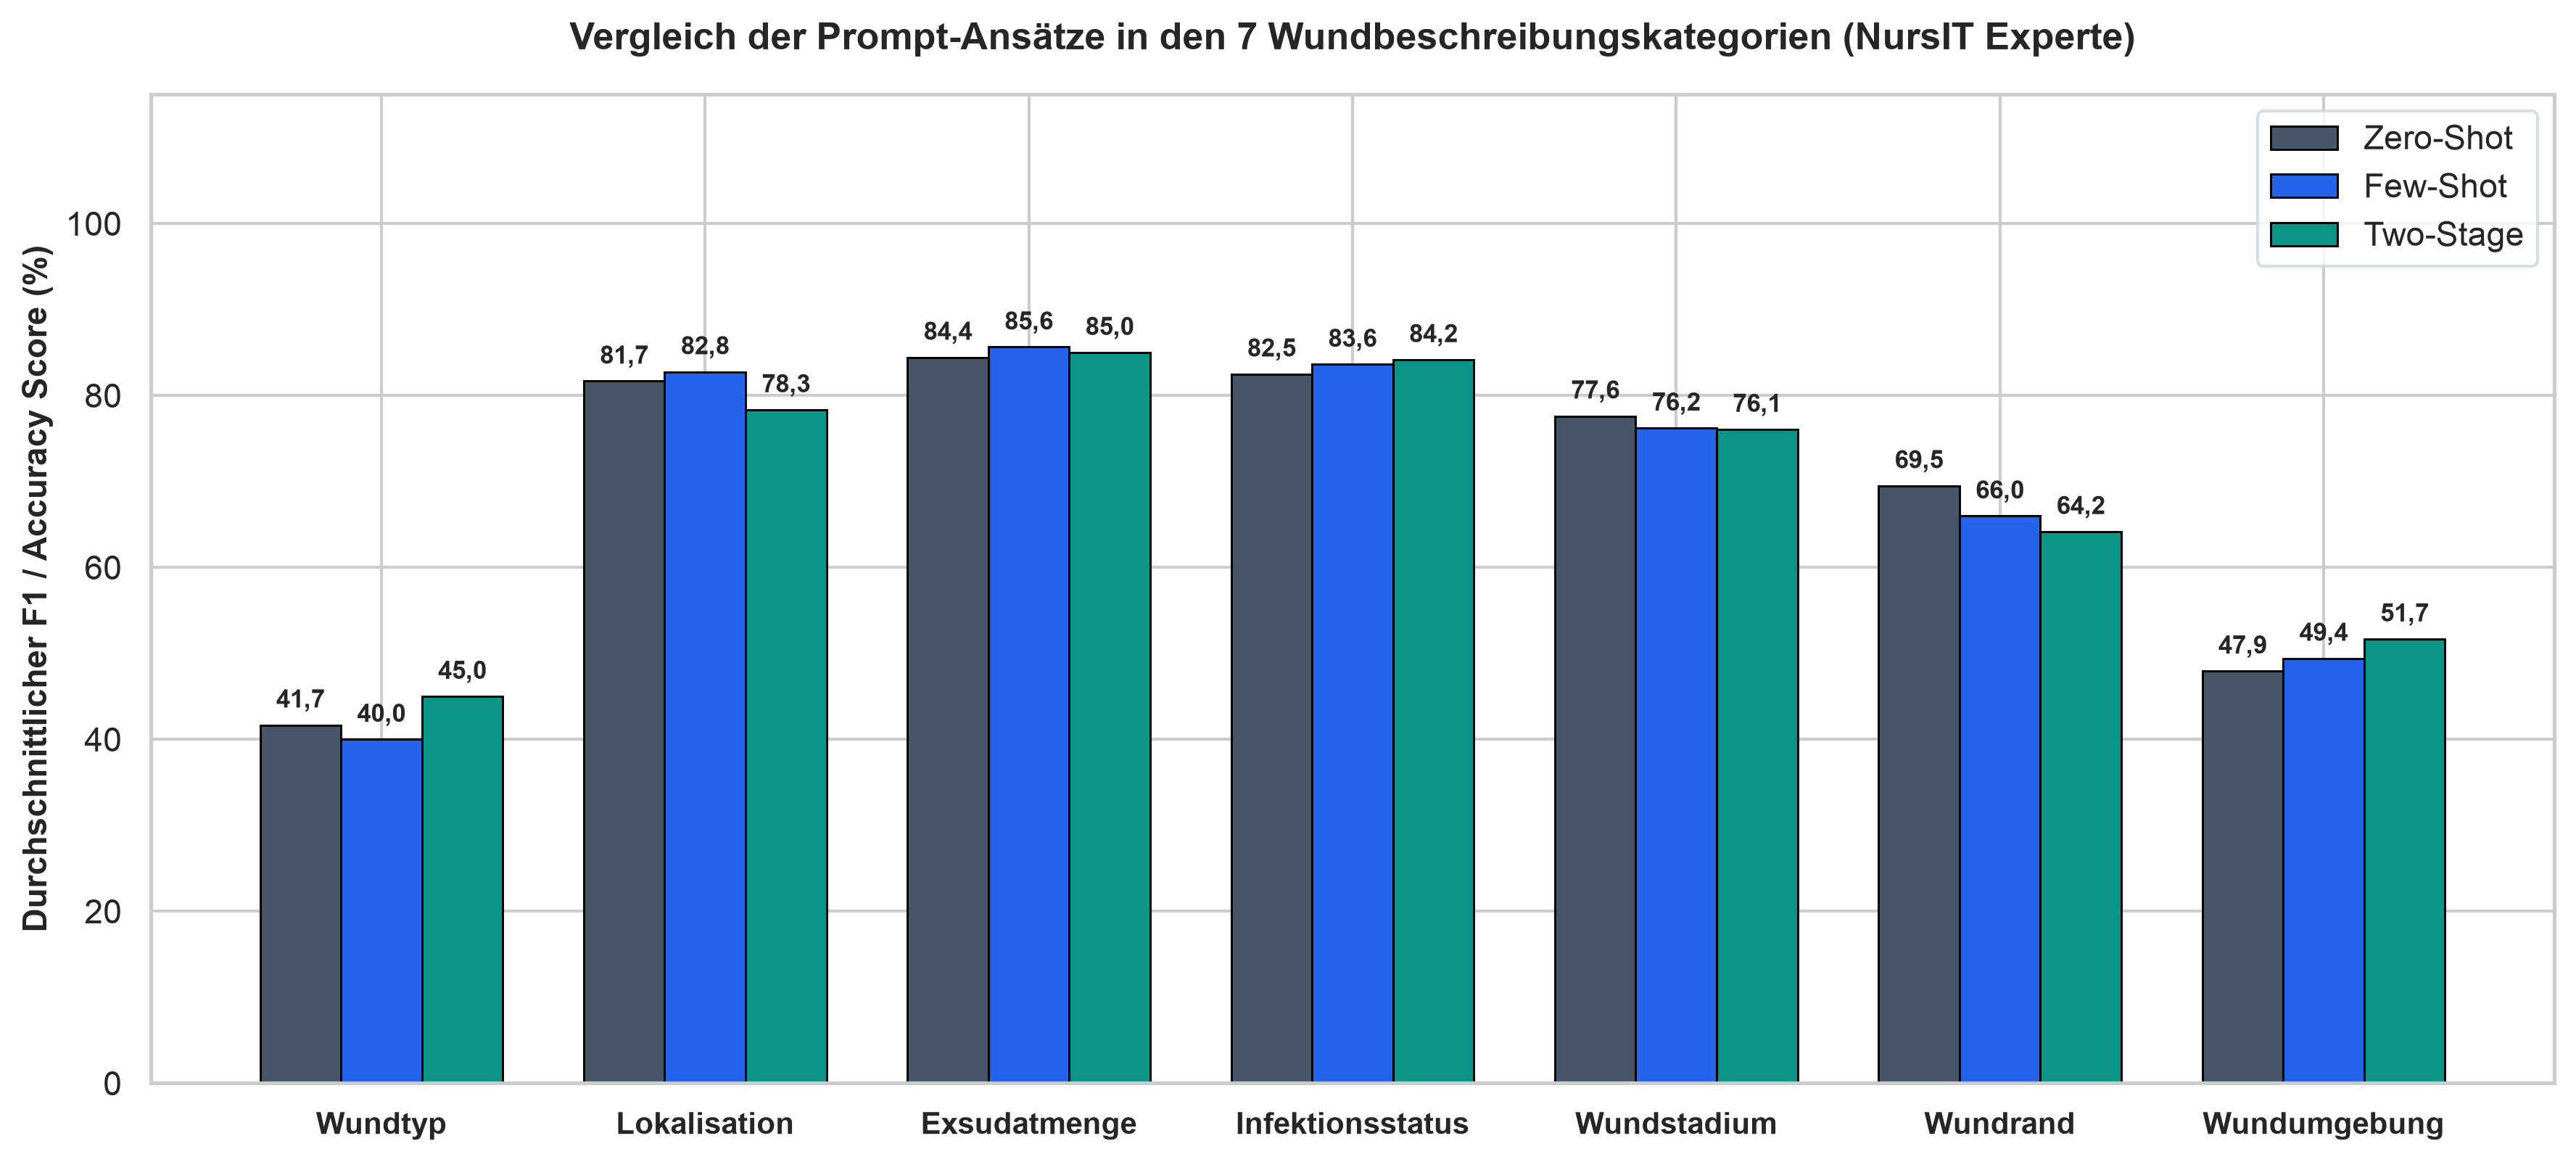

In [2]:
wund_rows = [
    "  Wundtyp (10/10)",
    "  Lokalisation (6/6)",
    "  Exsudatmenge (4/4)",
    "  Infektionsstatus (2/2)",
    "  Wundstadium (5/7)",
    "  Wundrand (7/7)",
    "  Wundumgebung (7/7)"
]
clean_labels = ["Wundtyp", "Lokalisation", "Exsudatmenge", "Infektionsstatus", "Wundstadium", "Wundrand", "Wundumgebung"]

df_wund = df_master.loc[wund_rows].copy()
df_wund.index = clean_labels

# 1. Tabelle & Plot Lohmann & Rauscher (Best-of-Both)
df_wund_lr = df_wund[["lr_ZS", "lr_FS", "lr_2S"]].copy()
df_wund_lr.columns = ["Zero-Shot", "Few-Shot", "Two-Stage"]
df_wund_lr["FS vs ZS (Δ)"] = df_wund_lr["Few-Shot"] - df_wund_lr["Zero-Shot"]
df_wund_lr["2S vs ZS (Δ)"] = df_wund_lr["Two-Stage"] - df_wund_lr["Zero-Shot"]
df_wund_lr["2S vs FS (Δ)"] = df_wund_lr["Two-Stage"] - df_wund_lr["Few-Shot"]

print("=== WUNDBESCHREIBUNG: LOHMANN & RAUSCHER (2 EXPERTEN) ===")
try:
    display(df_wund_lr.round(1))
except NameError:
    print(df_wund_lr.round(1))

sns.set_theme(style="whitegrid", font="sans-serif")
fig, ax = plt.subplots(figsize=(12, 5.5), dpi=300)
x = np.arange(len(clean_labels))
w = 0.25

ax.bar(x - w, df_wund_lr["Zero-Shot"], width=w, label="Zero-Shot", color="#475569", edgecolor="black", linewidth=0.7)
ax.bar(x, df_wund_lr["Few-Shot"], width=w, label="Few-Shot", color="#2563EB", edgecolor="black", linewidth=0.7)
ax.bar(x + w, df_wund_lr["Two-Stage"], width=w, label="Two-Stage", color="#0D9488", edgecolor="black", linewidth=0.7)

ax.set_xticks(x)
ax.set_xticklabels(clean_labels, fontweight="bold", fontsize=10)
ax.set_ylabel("Durchschnittlicher F1 / Accuracy Score (%)", fontweight="bold", fontsize=11)
ax.set_ylim(0, 115)
ax.set_title("Vergleich der Prompt-Ansätze in den 7 Wundbeschreibungskategorien (Lohmann & Rauscher)", fontweight="bold", fontsize=12.5, pad=15)
ax.legend(loc="upper right", frameon=True, facecolor="#FFFFFF", edgecolor="#CBD5E1")

for bar in ax.patches:
    val = bar.get_height()
    if val > 0:
        ax.annotate(f"{val:.1f}".replace(".", ","), xy=(bar.get_x() + bar.get_width()/2, val), xytext=(0, 4),
                    textcoords="offset points", ha="center", va="bottom", fontsize=8.5, fontweight="bold")

plt.tight_layout()
os.makedirs("../../exports/pngs", exist_ok=True)
plt.savefig("../../exports/pngs/prompt_ansatze_wundbeschreibung_detail.png", dpi=300, bbox_inches="tight")
plt.show()

# 2. Tabelle & Plot NursIT (Experte 3)
df_wund_nu = df_wund[["nurs_ZS", "nurs_FS", "nurs_2S"]].copy()
df_wund_nu.columns = ["Zero-Shot", "Few-Shot", "Two-Stage"]
df_wund_nu["FS vs ZS (Δ)"] = df_wund_nu["Few-Shot"] - df_wund_nu["Zero-Shot"]
df_wund_nu["2S vs ZS (Δ)"] = df_wund_nu["Two-Stage"] - df_wund_nu["Zero-Shot"]
df_wund_nu["2S vs FS (Δ)"] = df_wund_nu["Two-Stage"] - df_wund_nu["Few-Shot"]

print("\n=== WUNDBESCHREIBUNG: NURSIT (EXPERTE 3) ===")
try:
    display(df_wund_nu.round(1))
except NameError:
    print(df_wund_nu.round(1))

fig, ax = plt.subplots(figsize=(12, 5.5), dpi=300)

ax.bar(x - w, df_wund_nu["Zero-Shot"], width=w, label="Zero-Shot", color="#475569", edgecolor="black", linewidth=0.7)
ax.bar(x, df_wund_nu["Few-Shot"], width=w, label="Few-Shot", color="#2563EB", edgecolor="black", linewidth=0.7)
ax.bar(x + w, df_wund_nu["Two-Stage"], width=w, label="Two-Stage", color="#0D9488", edgecolor="black", linewidth=0.7)

ax.set_xticks(x)
ax.set_xticklabels(clean_labels, fontweight="bold", fontsize=10)
ax.set_ylabel("Durchschnittlicher F1 / Accuracy Score (%)", fontweight="bold", fontsize=11)
ax.set_ylim(0, 115)
ax.set_title("Vergleich der Prompt-Ansätze in den 7 Wundbeschreibungskategorien (NursIT Experte)", fontweight="bold", fontsize=12.5, pad=15)
ax.legend(loc="upper right", frameon=True, facecolor="#FFFFFF", edgecolor="#CBD5E1")

for bar in ax.patches:
    val = bar.get_height()
    if val > 0:
        ax.annotate(f"{val:.1f}".replace(".", ","), xy=(bar.get_x() + bar.get_width()/2, val), xytext=(0, 4),
                    textcoords="offset points", ha="center", va="bottom", fontsize=8.5, fontweight="bold")

plt.tight_layout()
plt.savefig("../../exports/pngs/prompt_ansatze_wundbeschreibung_detail_nursit.png", dpi=300, bbox_inches="tight")
plt.show()

## 2. Hauptkategorien-Vergleich & Prozentuale Differenzen (Deltas)

Hier vergleichen wir die 5 Hauptkategorien gegeneinander. Wir berechnen für jede Kategorie:
- **Few-Shot vs. Zero-Shot (Δ):** Gewinn/Verlust durch Few-Shot Beispiele im Prompt
- **Two-Stage vs. Zero-Shot (Δ):** Gewinn/Verlust durch die zweistufige Prozess-Entkopplung
- **Two-Stage vs. Few-Shot (Δ):** Direktvergleich der beiden fortgeschrittenen Ansätze

In [3]:
# Berechne Mittelwert Wundbeschreibung
wund_mean_lr = df_master.loc[wund_rows, ["lr_ZS", "lr_FS", "lr_2S"]].mean()
wund_mean_nu = df_master.loc[wund_rows, ["nurs_ZS", "nurs_FS", "nurs_2S"]].mean()

cat_map_lr = {
    "Wundbeschreibung (Mittelwert)": wund_mean_lr,
    "Debridement Methode": df_master.loc["  Debridement Methode (5/8)", ["lr_ZS", "lr_FS", "lr_2S"]],
    "Primärverband (Level 2)": df_master.loc["  Primärverband (9/16)", ["lr_ZS", "lr_FS", "lr_2S"]],
    "Sekundärverband": df_master.loc["  Sekundärverband (4/12)", ["lr_ZS", "lr_FS", "lr_2S"]],
    "Kompressionsprodukt": df_master.loc["  Kompressionsprodukte (5/37)", ["lr_ZS", "lr_FS", "lr_2S"]]
}

df_summary_lr = pd.DataFrame(cat_map_lr).T
df_summary_lr.columns = ["Zero-Shot", "Few-Shot", "Two-Stage"]
df_summary_lr["FS vs ZS (Δ)"] = df_summary_lr["Few-Shot"] - df_summary_lr["Zero-Shot"]
df_summary_lr["2S vs ZS (Δ)"] = df_summary_lr["Two-Stage"] - df_summary_lr["Zero-Shot"]
df_summary_lr["2S vs FS (Δ)"] = df_summary_lr["Two-Stage"] - df_summary_lr["Few-Shot"]

print("=== LOHMANN & RAUSCHER (2 EXPERTEN KONSENS): HAUPTKATEGORIEN ===")
try:
    display(df_summary_lr.round(1))
except NameError:
    print(df_summary_lr.round(1))

cat_map_nu = {
    "Wundbeschreibung (Mittelwert)": wund_mean_nu,
    "Debridement Methode": df_master.loc["  Debridement Methode (5/8)", ["nurs_ZS", "nurs_FS", "nurs_2S"]],
    "Primärverband (Level 2)": df_master.loc["  Primärverband (9/16)", ["nurs_ZS", "nurs_FS", "nurs_2S"]],
    "Sekundärverband": df_master.loc["  Sekundärverband (4/12)", ["nurs_ZS", "nurs_FS", "nurs_2S"]],
    "Kompressionsprodukt": df_master.loc["  Kompressionsprodukte (5/37)", ["nurs_ZS", "nurs_FS", "nurs_2S"]]
}

df_summary_nu = pd.DataFrame(cat_map_nu).T
df_summary_nu.columns = ["Zero-Shot", "Few-Shot", "Two-Stage"]
df_summary_nu["FS vs ZS (Δ)"] = df_summary_nu["Few-Shot"] - df_summary_nu["Zero-Shot"]
df_summary_nu["2S vs ZS (Δ)"] = df_summary_nu["Two-Stage"] - df_summary_nu["Zero-Shot"]
df_summary_nu["2S vs FS (Δ)"] = df_summary_nu["Two-Stage"] - df_summary_nu["Few-Shot"]

print("\n=== NURSIT (EXPERTE 3): HAUPTKATEGORIEN ===")
try:
    display(df_summary_nu.round(1))
except NameError:
    print(df_summary_nu.round(1))

=== LOHMANN & RAUSCHER (2 EXPERTEN KONSENS): HAUPTKATEGORIEN ===


,Zero-Shot,Few-Shot,Two-Stage,FS vs ZS (Δ),2S vs ZS (Δ),2S vs FS (Δ)
Wundbeschreibung (Mittelwert),76.3,77.8,76.6,1.5,0.4,-1.2
Debridement Methode,52.1,53.4,57.6,1.3,5.5,4.2
Primärverband (Level 2),62.1,64.7,70.4,2.6,8.3,5.7
Sekundärverband,6.7,23.3,5.0,16.7,-1.7,-18.3
Kompressionsprodukt,10.3,12.2,10.3,1.9,0.0,-1.9



=== NURSIT (EXPERTE 3): HAUPTKATEGORIEN ===


,Zero-Shot,Few-Shot,Two-Stage,FS vs ZS (Δ),2S vs ZS (Δ),2S vs FS (Δ)
Wundbeschreibung (Mittelwert),69.3,69.1,69.2,-0.2,-0.1,0.1
Debridement Methode,58.3,55.4,63.6,-3.0,5.2,8.2
Primärverband (Level 2),64.0,63.6,61.6,-0.4,-2.4,-2.0
Sekundärverband,4.4,4.0,7.3,-0.4,2.8,3.3
Kompressionsprodukt,0.0,12.8,2.1,12.8,2.1,-10.7


## 3. Visuelle Aufbereitung: Differenzen & Prompt-Vergleiche (Deltas in Prozentpunkten %)

Visualisierung der Gewinne/Verluste in Prozentpunkten durch den Einsatz von Few-Shot und Two-Stage sowohl für **Lohmann & Rauscher** als auch für den **NursIT Experten**.

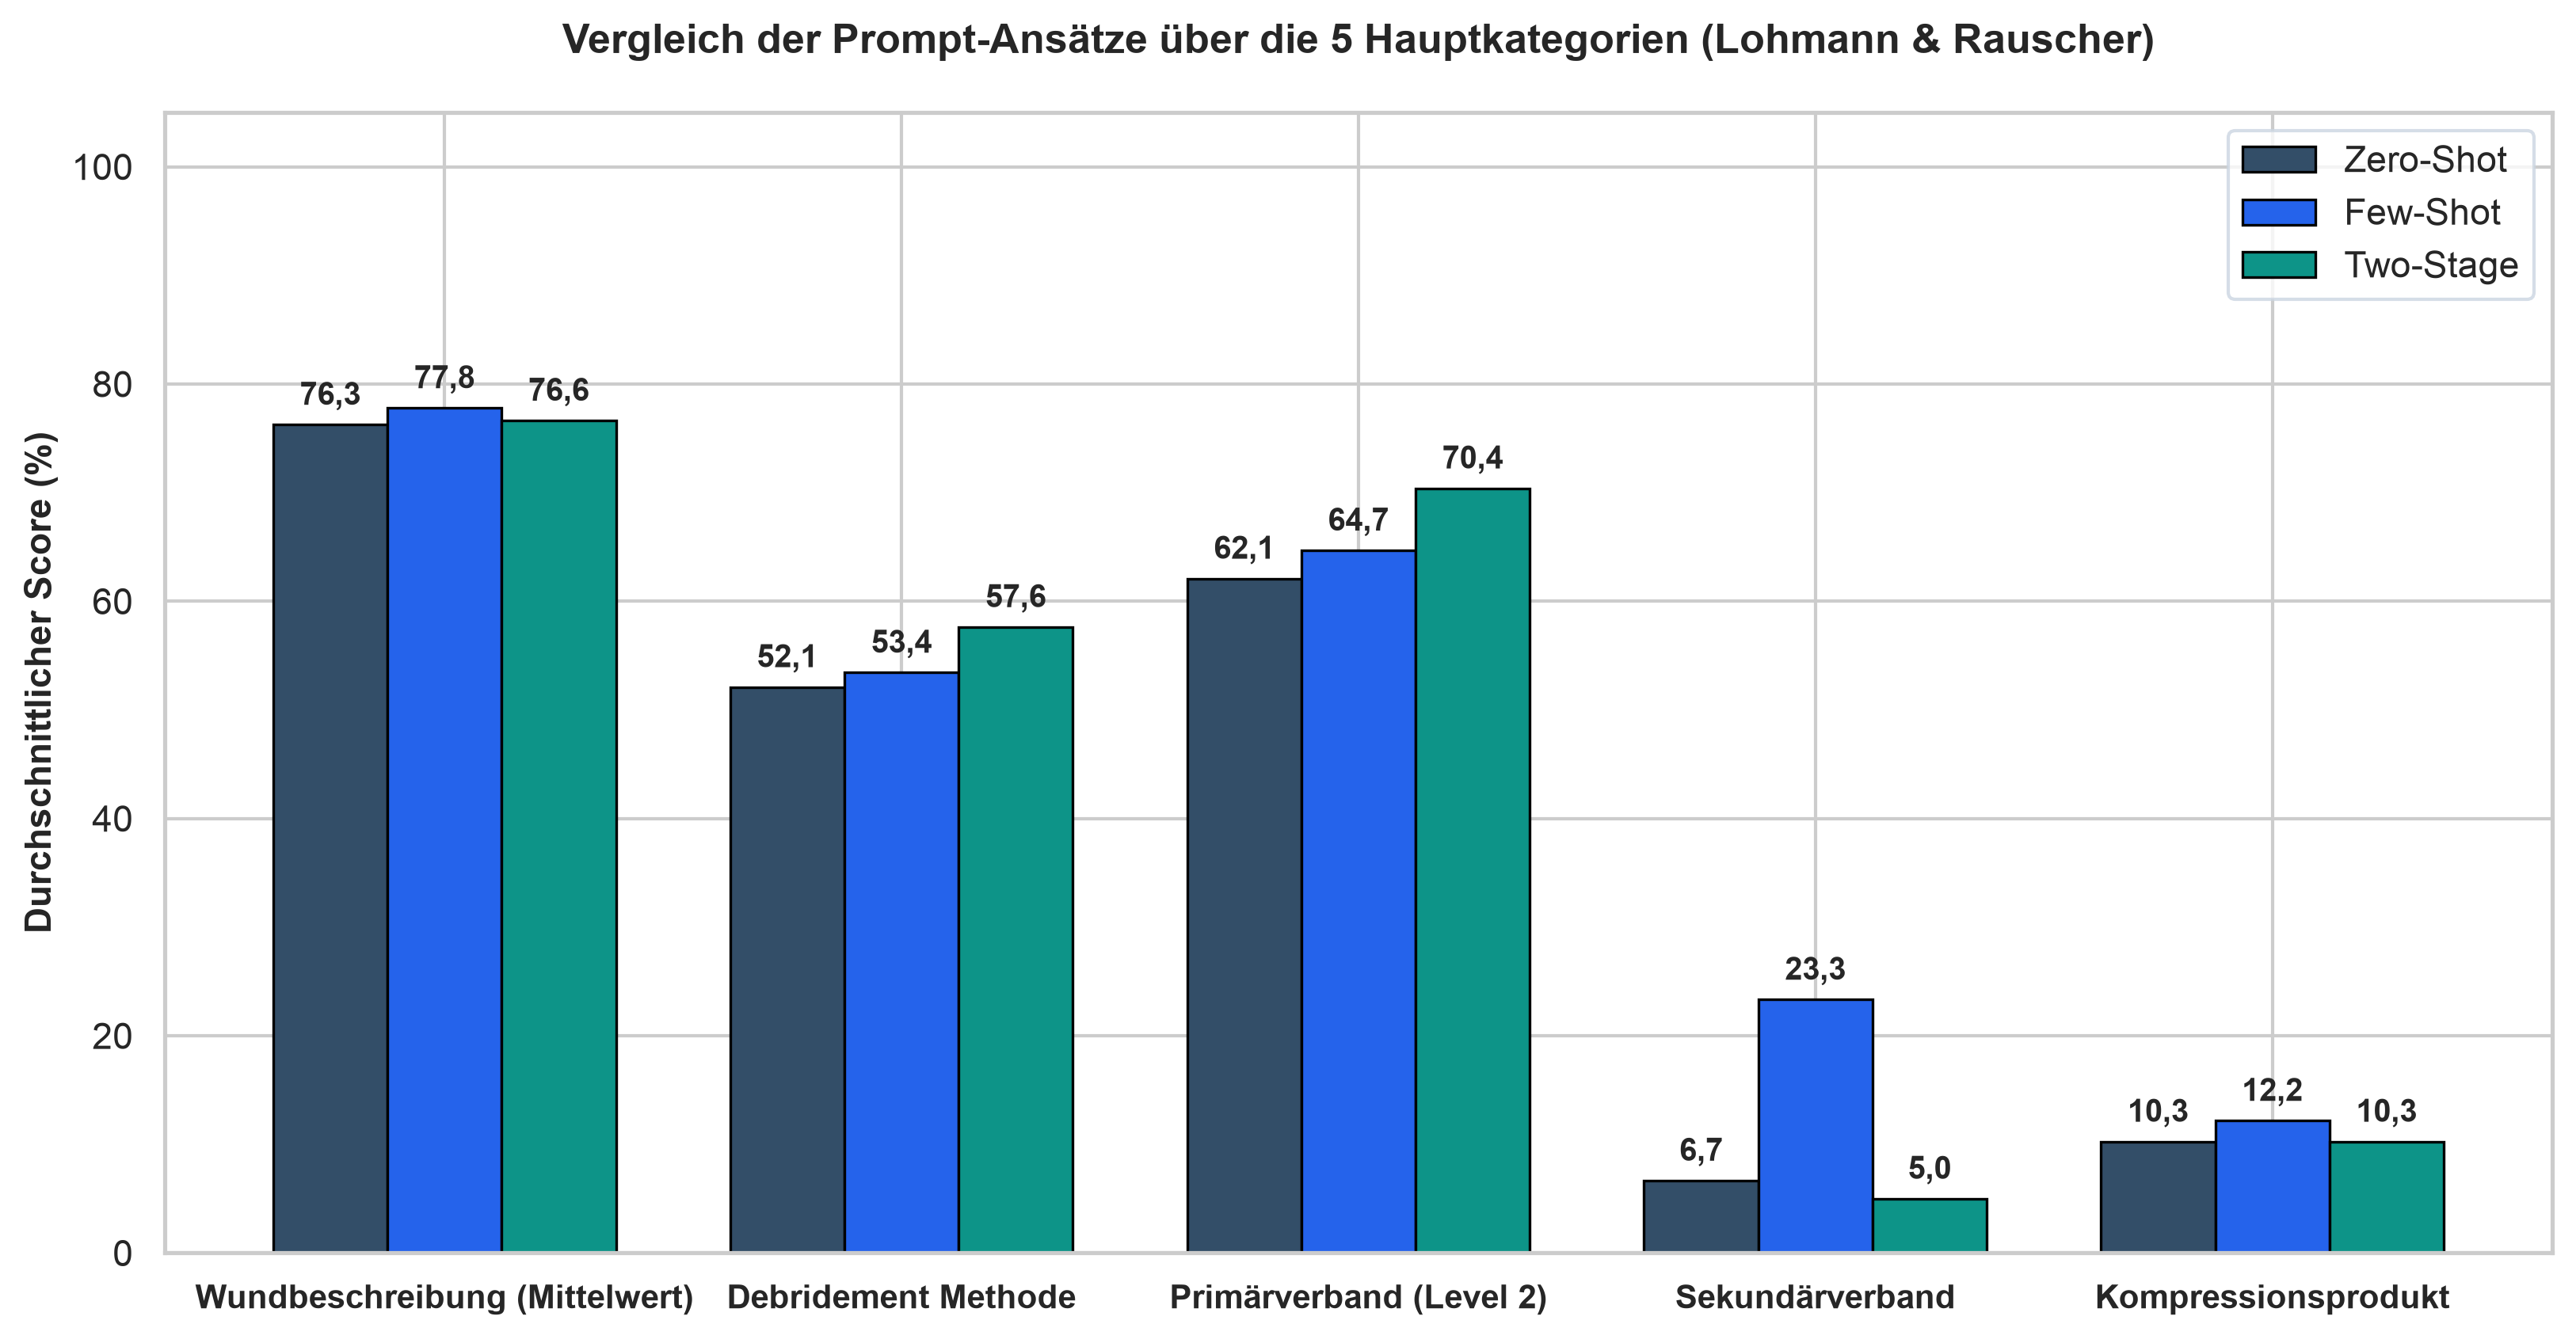

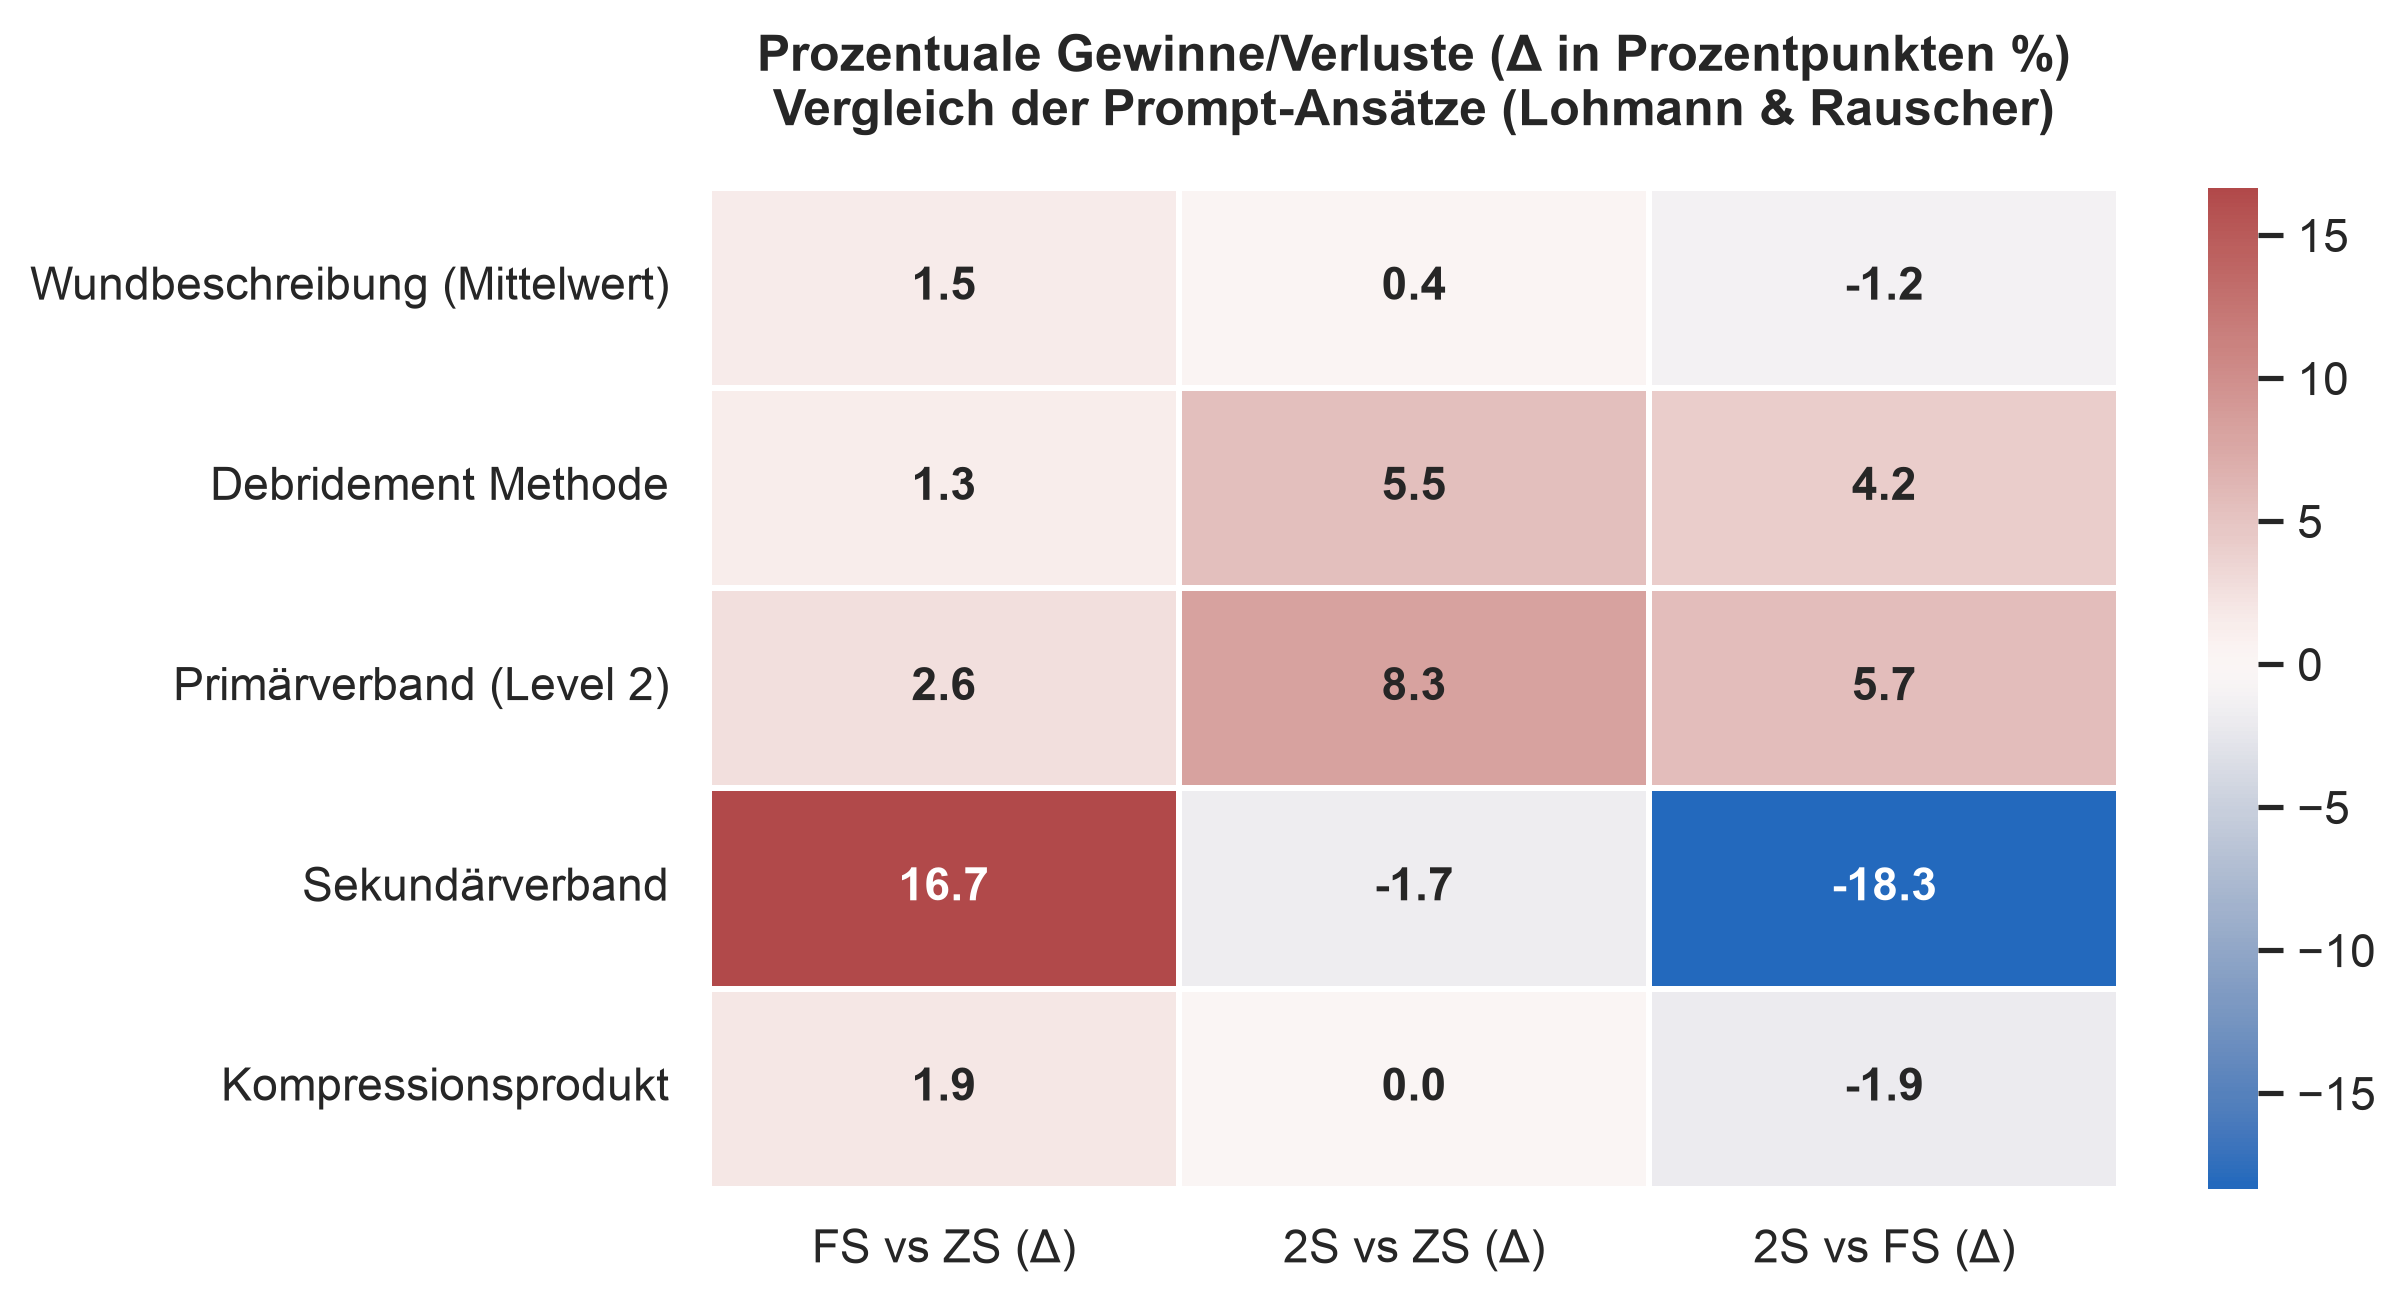

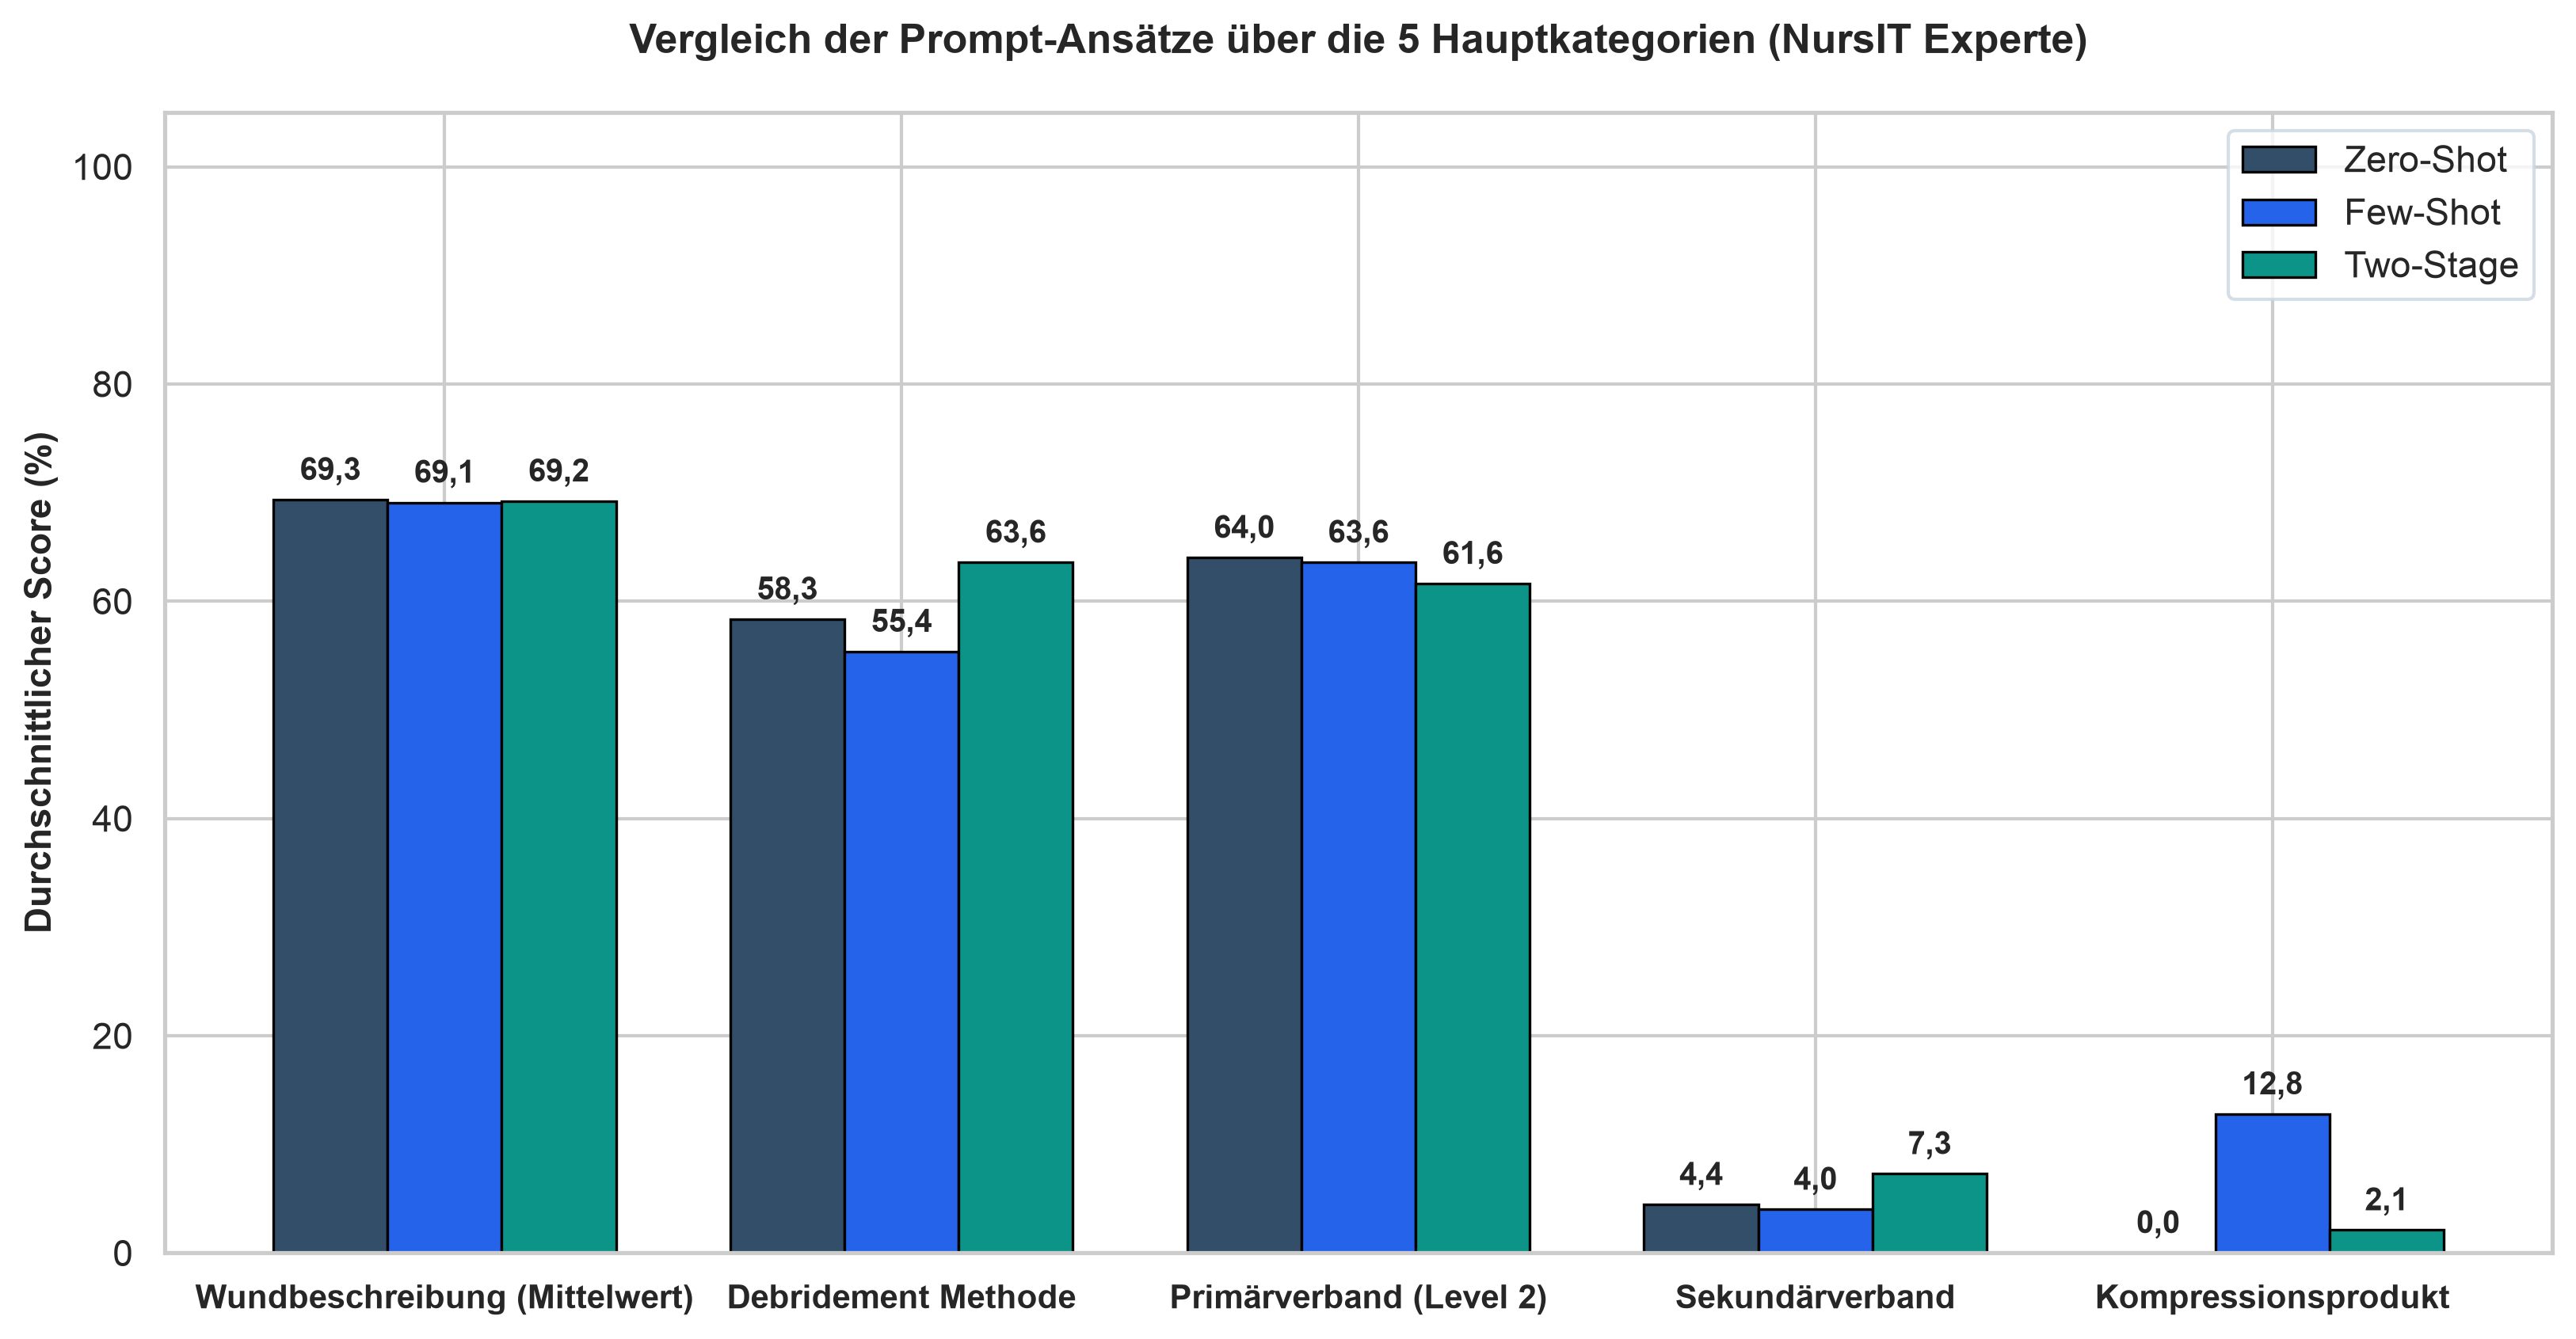

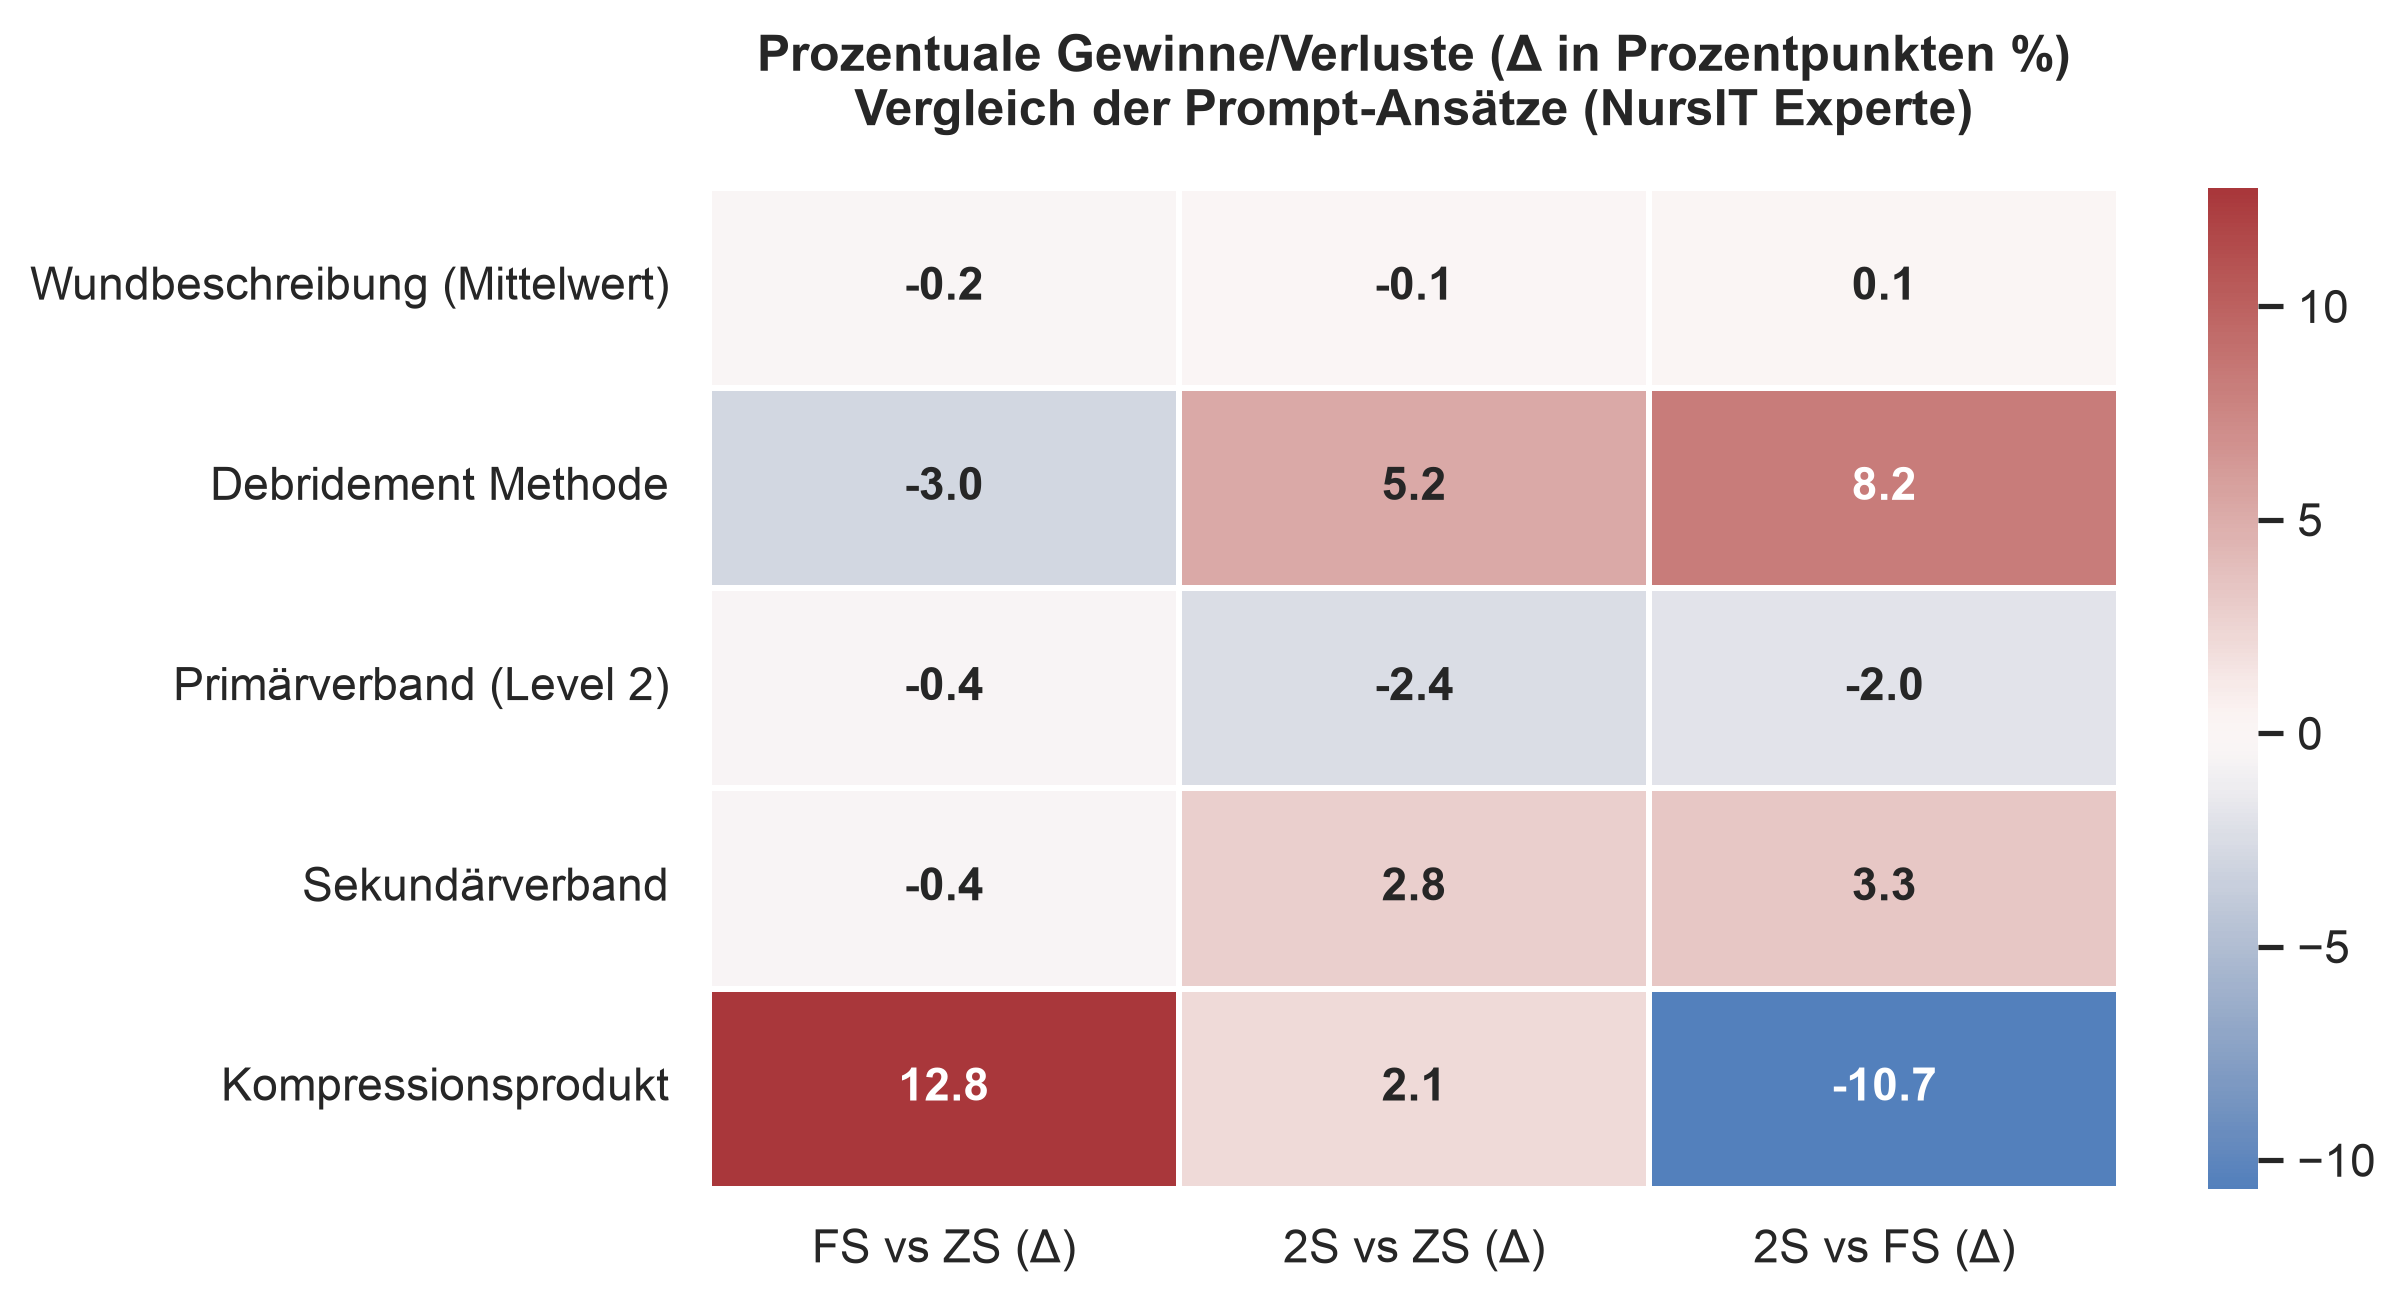

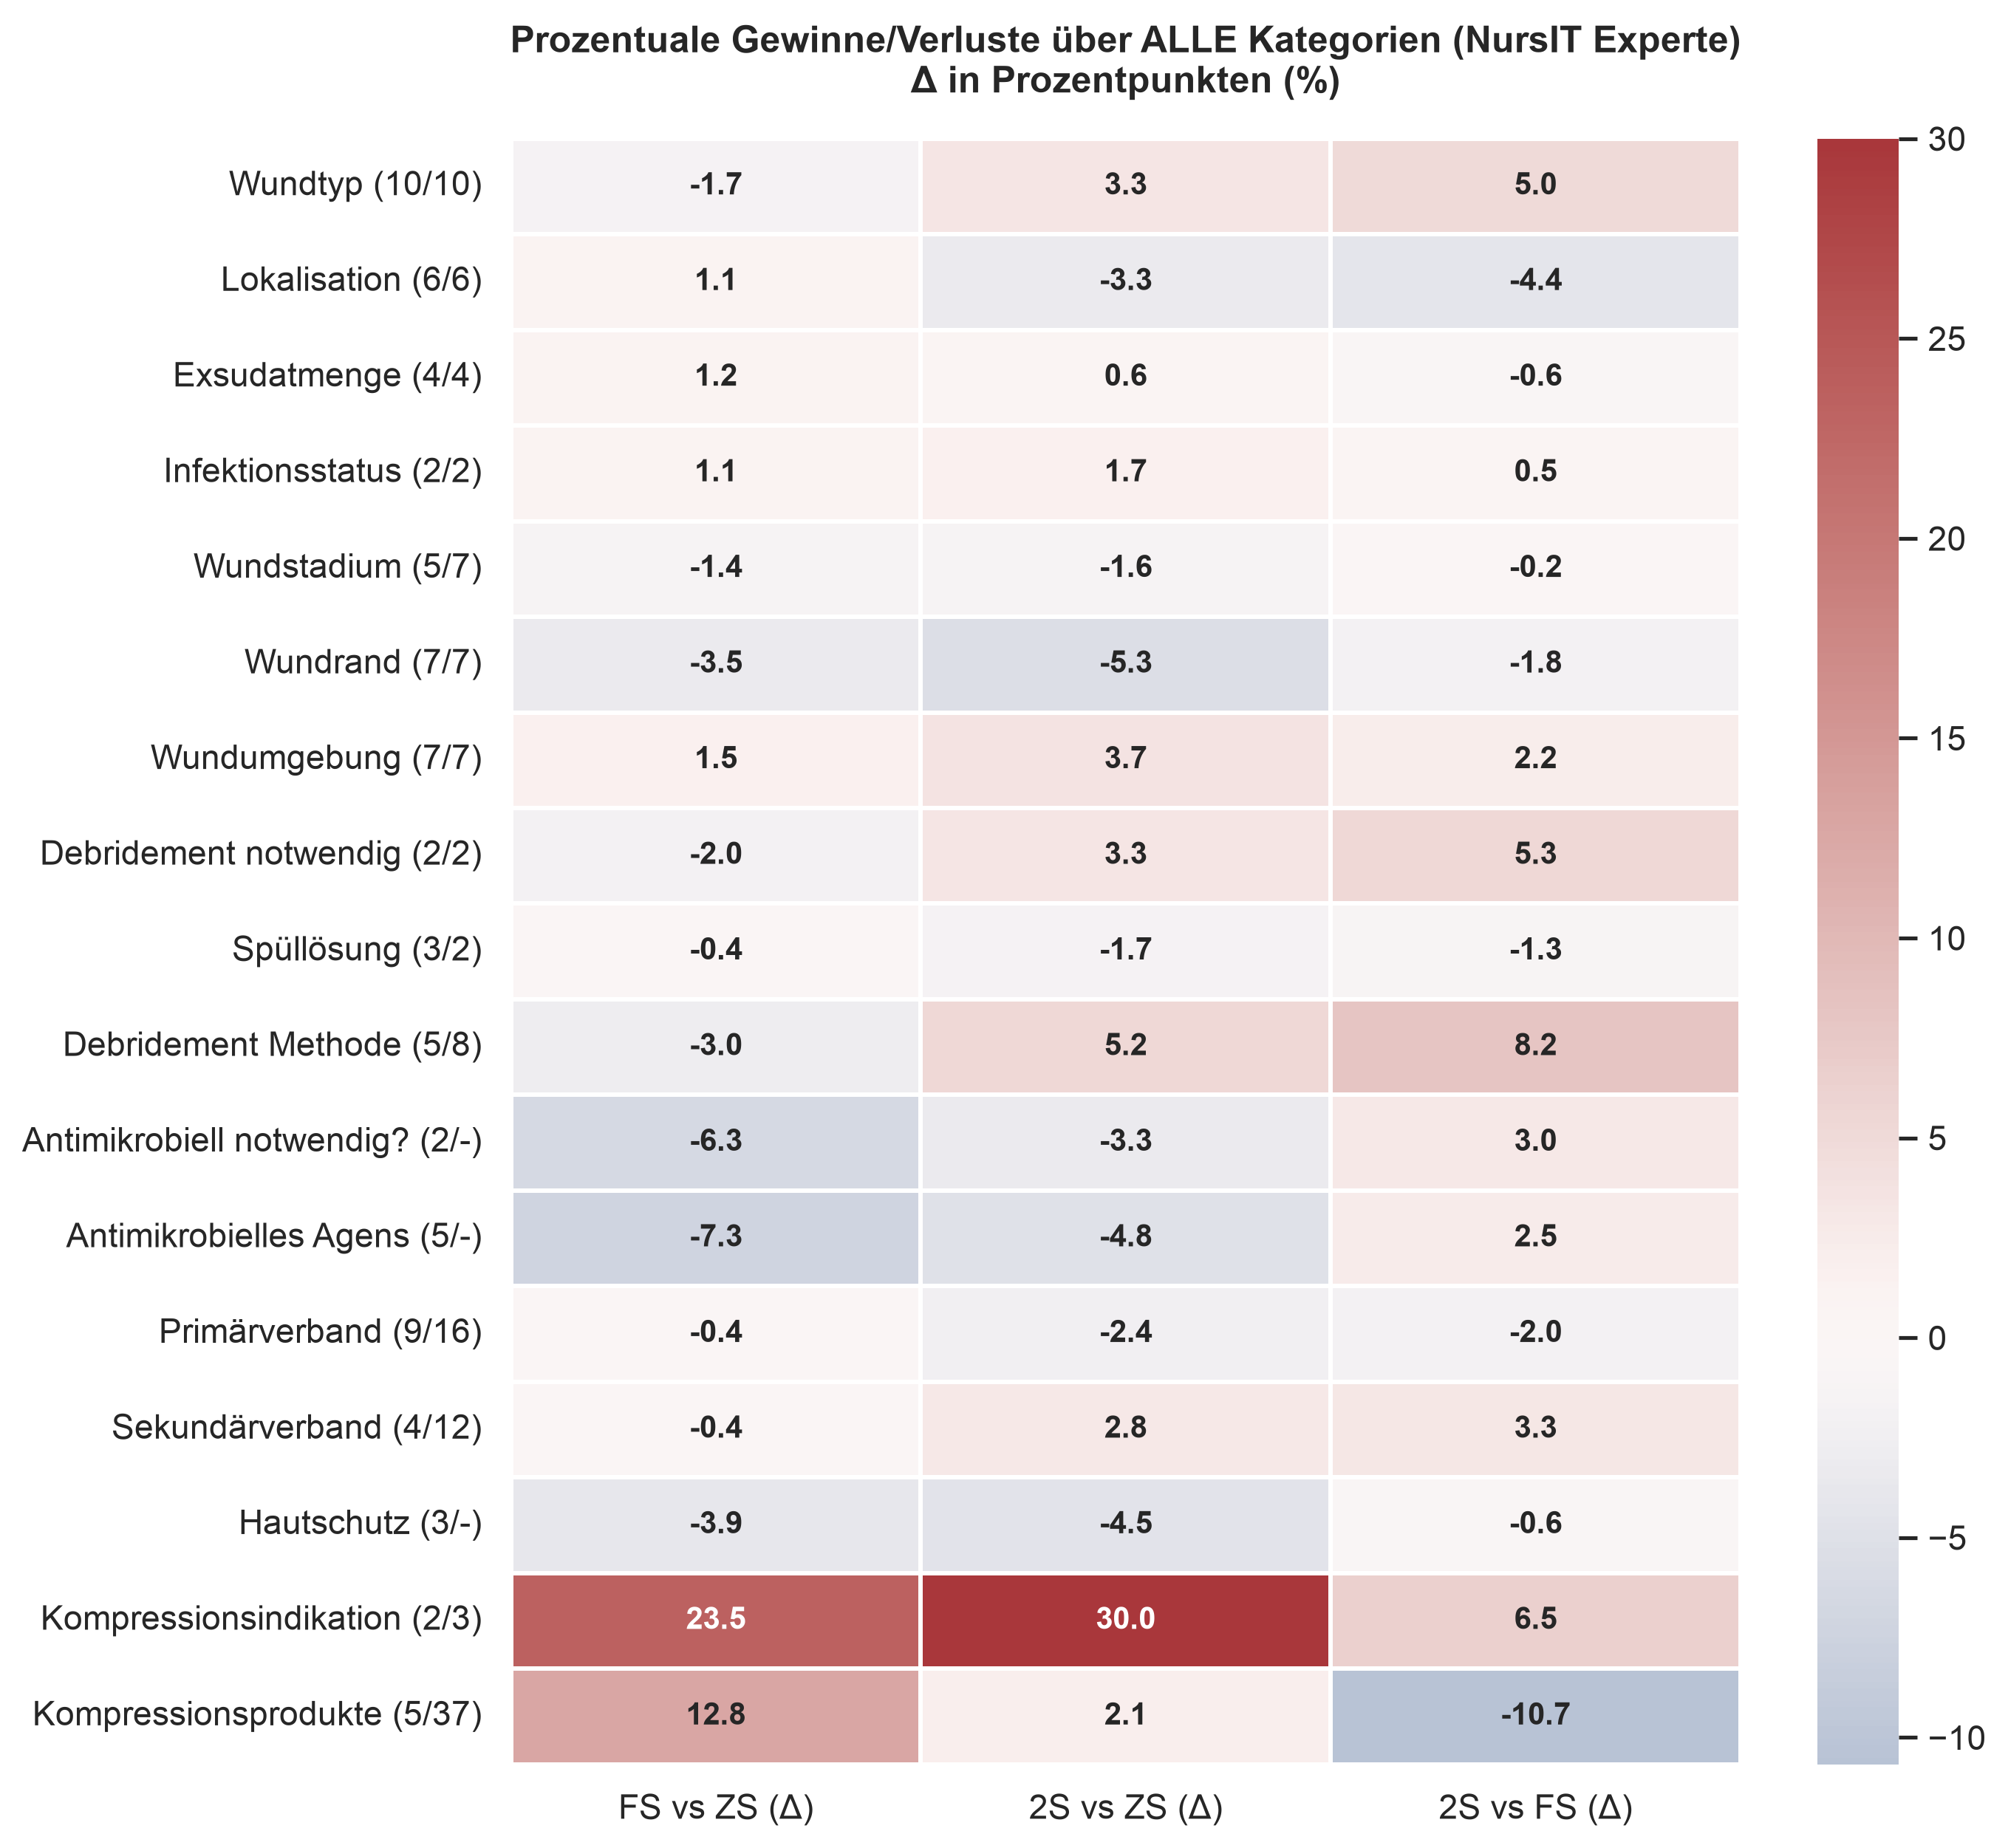

In [4]:
# 1. Master Bar Plot & Heatmap der 5 Hauptkategorien für Lohmann & Rauscher
fig, ax = plt.subplots(figsize=(11, 5.8), dpi=300)
cats = df_summary_lr.index.tolist()
x = np.arange(len(cats))
w = 0.25

bars1 = ax.bar(x - w, df_summary_lr["Zero-Shot"], width=w, label="Zero-Shot", color="#334E68", edgecolor="black", linewidth=0.8)
bars2 = ax.bar(x, df_summary_lr["Few-Shot"], width=w, label="Few-Shot", color="#2563EB", edgecolor="black", linewidth=0.8)
bars3 = ax.bar(x + w, df_summary_lr["Two-Stage"], width=w, label="Two-Stage", color="#0D9488", edgecolor="black", linewidth=0.8)

ax.set_xticks(x)
ax.set_xticklabels(cats, fontweight="bold", fontsize=10)
ax.set_ylabel("Durchschnittlicher Score (%)", fontweight="bold", fontsize=11)
ax.set_ylim(0, 105)
ax.set_title("Vergleich der Prompt-Ansätze über die 5 Hauptkategorien (Lohmann & Rauscher)", fontweight="bold", fontsize=12.5, pad=18)
ax.legend(loc="upper right", frameon=True, facecolor="#FFFFFF", edgecolor="#CBD5E1")

for bar in list(bars1) + list(bars2) + list(bars3):
    val = bar.get_height()
    if val > 0:
        ax.annotate(f"{val:.1f}".replace(".", ","), xy=(bar.get_x() + bar.get_width()/2, val), xytext=(0, 4),
                    textcoords="offset points", ha="center", va="bottom", fontsize=9.5, fontweight="bold")

plt.tight_layout()
plt.savefig("../../exports/pngs/prompt_ansatze_hauptkategorien_vergleich.png", dpi=300, bbox_inches="tight")
plt.show()

# Heatmap der Deltas L&R
df_delta_lr = df_summary_lr[["FS vs ZS (Δ)", "2S vs ZS (Δ)", "2S vs FS (Δ)"]].copy()
fig, ax = plt.subplots(figsize=(8.5, 4.5), dpi=300)
sns.heatmap(df_delta_lr, annot=True, fmt=".1f", cmap="vlag", center=0, cbar=True, ax=ax, linewidths=1.0, annot_kws={"fontweight": "bold", "fontsize": 11})
ax.set_title("Prozentuale Gewinne/Verluste (Δ in Prozentpunkten %)\nVergleich der Prompt-Ansätze (Lohmann & Rauscher)", fontweight="bold", fontsize=12, pad=15)
plt.tight_layout()
plt.savefig("../../exports/pngs/prompt_ansatze_delta_heatmap.png", dpi=300, bbox_inches="tight")
plt.show()

# 2. Master Bar Plot & Heatmap der 5 Hauptkategorien für NursIT (Experte 3)
fig, ax = plt.subplots(figsize=(11, 5.8), dpi=300)

bars1_n = ax.bar(x - w, df_summary_nu["Zero-Shot"], width=w, label="Zero-Shot", color="#334E68", edgecolor="black", linewidth=0.8)
bars2_n = ax.bar(x, df_summary_nu["Few-Shot"], width=w, label="Few-Shot", color="#2563EB", edgecolor="black", linewidth=0.8)
bars3_n = ax.bar(x + w, df_summary_nu["Two-Stage"], width=w, label="Two-Stage", color="#0D9488", edgecolor="black", linewidth=0.8)

ax.set_xticks(x)
ax.set_xticklabels(cats, fontweight="bold", fontsize=10)
ax.set_ylabel("Durchschnittlicher Score (%)", fontweight="bold", fontsize=11)
ax.set_ylim(0, 105)
ax.set_title("Vergleich der Prompt-Ansätze über die 5 Hauptkategorien (NursIT Experte)", fontweight="bold", fontsize=12.5, pad=18)
ax.legend(loc="upper right", frameon=True, facecolor="#FFFFFF", edgecolor="#CBD5E1")

for bar in list(bars1_n) + list(bars2_n) + list(bars3_n):
    val = bar.get_height()
    if val >= 0:
        ax.annotate(f"{val:.1f}".replace(".", ","), xy=(bar.get_x() + bar.get_width()/2, val), xytext=(0, 4),
                    textcoords="offset points", ha="center", va="bottom", fontsize=9.5, fontweight="bold")

plt.tight_layout()
plt.savefig("../../exports/pngs/prompt_ansatze_hauptkategorien_vergleich_nursit.png", dpi=300, bbox_inches="tight")
plt.show()

# Heatmap der Deltas NursIT
df_delta_nu = df_summary_nu[["FS vs ZS (Δ)", "2S vs ZS (Δ)", "2S vs FS (Δ)"]].copy()
fig, ax = plt.subplots(figsize=(8.5, 4.5), dpi=300)
sns.heatmap(df_delta_nu, annot=True, fmt=".1f", cmap="vlag", center=0, cbar=True, ax=ax, linewidths=1.0, annot_kws={"fontweight": "bold", "fontsize": 11})
ax.set_title("Prozentuale Gewinne/Verluste (Δ in Prozentpunkten %)\nVergleich der Prompt-Ansätze (NursIT Experte)", fontweight="bold", fontsize=12, pad=15)
plt.tight_layout()
plt.savefig("../../exports/pngs/prompt_ansatze_delta_heatmap_nursit.png", dpi=300, bbox_inches="tight")
plt.show()

# 3. Deltas über ALLE Einzelkategorien für den NursIT Experten
df_nurs_all = df_master[["nurs_ZS", "nurs_FS", "nurs_2S"]].dropna(how="all").copy()
df_nurs_all.columns = ["Zero-Shot", "Few-Shot", "Two-Stage"]
df_nurs_all["FS vs ZS (Δ)"] = df_nurs_all["Few-Shot"] - df_nurs_all["Zero-Shot"]
df_nurs_all["2S vs ZS (Δ)"] = df_nurs_all["Two-Stage"] - df_nurs_all["Zero-Shot"]
df_nurs_all["2S vs FS (Δ)"] = df_nurs_all["Two-Stage"] - df_nurs_all["Few-Shot"]

clean_index_all = [idx.strip() for idx in df_nurs_all.index]
df_nurs_all.index = clean_index_all

df_delta_nurs_all = df_nurs_all[["FS vs ZS (Δ)", "2S vs ZS (Δ)", "2S vs FS (Δ)"]].copy()

fig, ax = plt.subplots(figsize=(9.5, 8.5), dpi=300)
sns.heatmap(df_delta_nurs_all, annot=True, fmt=".1f", cmap="vlag", center=0, cbar=True, ax=ax, linewidths=1.0, annot_kws={"fontweight": "bold", "fontsize": 10})
ax.set_title("Prozentuale Gewinne/Verluste über ALLE Kategorien (NursIT Experte)\nΔ in Prozentpunkten (%)", fontweight="bold", fontsize=12, pad=15)
plt.tight_layout()
plt.savefig("../../exports/pngs/prompt_ansatze_delta_heatmap_nursit_alle_kategorien.png", dpi=300, bbox_inches="tight")
plt.show()

## 4. Gesamtschau über ALLE 3 EXPERTEN: Wundbeschreibung & Primärverband (Level 3)

Hier aggregieren wir alle **3 klinischen Experten** (Experte 1 & 2 von L&R sowie Experte 3 von NursIT) in eine einheitliche Gesamtevaluation. Der Fokus liegt exklusiv auf:
1. Den **7 Merkmals-Kategorien der Wundbeschreibung** (+ deren Gesamt-Mittelwert)
2. Dem **Primärverband auf Ebene 3** (Verbandsklassen-Ebene)

=== 3 EXPERTEN KONSENS / GESAMTSCHAU (WUNDBESCHREIBUNG & PRIMÄRVERBAND LEVEL 3) ===


,Zero-Shot,Few-Shot,Two-Stage,FS vs ZS (Δ),2S vs ZS (Δ),2S vs FS (Δ)
Wundtyp,46.1,56.7,57.2,10.6,11.1,0.6
Lokalisation,83.9,87.4,82.8,3.5,-1.1,-4.6
Exsudatmenge,89.4,87.9,88.7,-1.4,-0.7,0.7
Infektionsstatus,91.9,89.9,91.4,-2.0,-0.6,1.4
Wundstadium,75.1,77.1,76.8,2.0,1.7,-0.3
Wundrand,69.9,69.0,66.1,-0.9,-3.9,-3.0
Wundumgebung,61.3,56.1,56.2,-5.1,-5.1,0.0
Wundbeschreibung (Ø),74.0,74.9,74.2,0.9,0.2,-0.7
Primärverband (Level 3),63.4,65.5,68.7,2.0,5.3,3.3


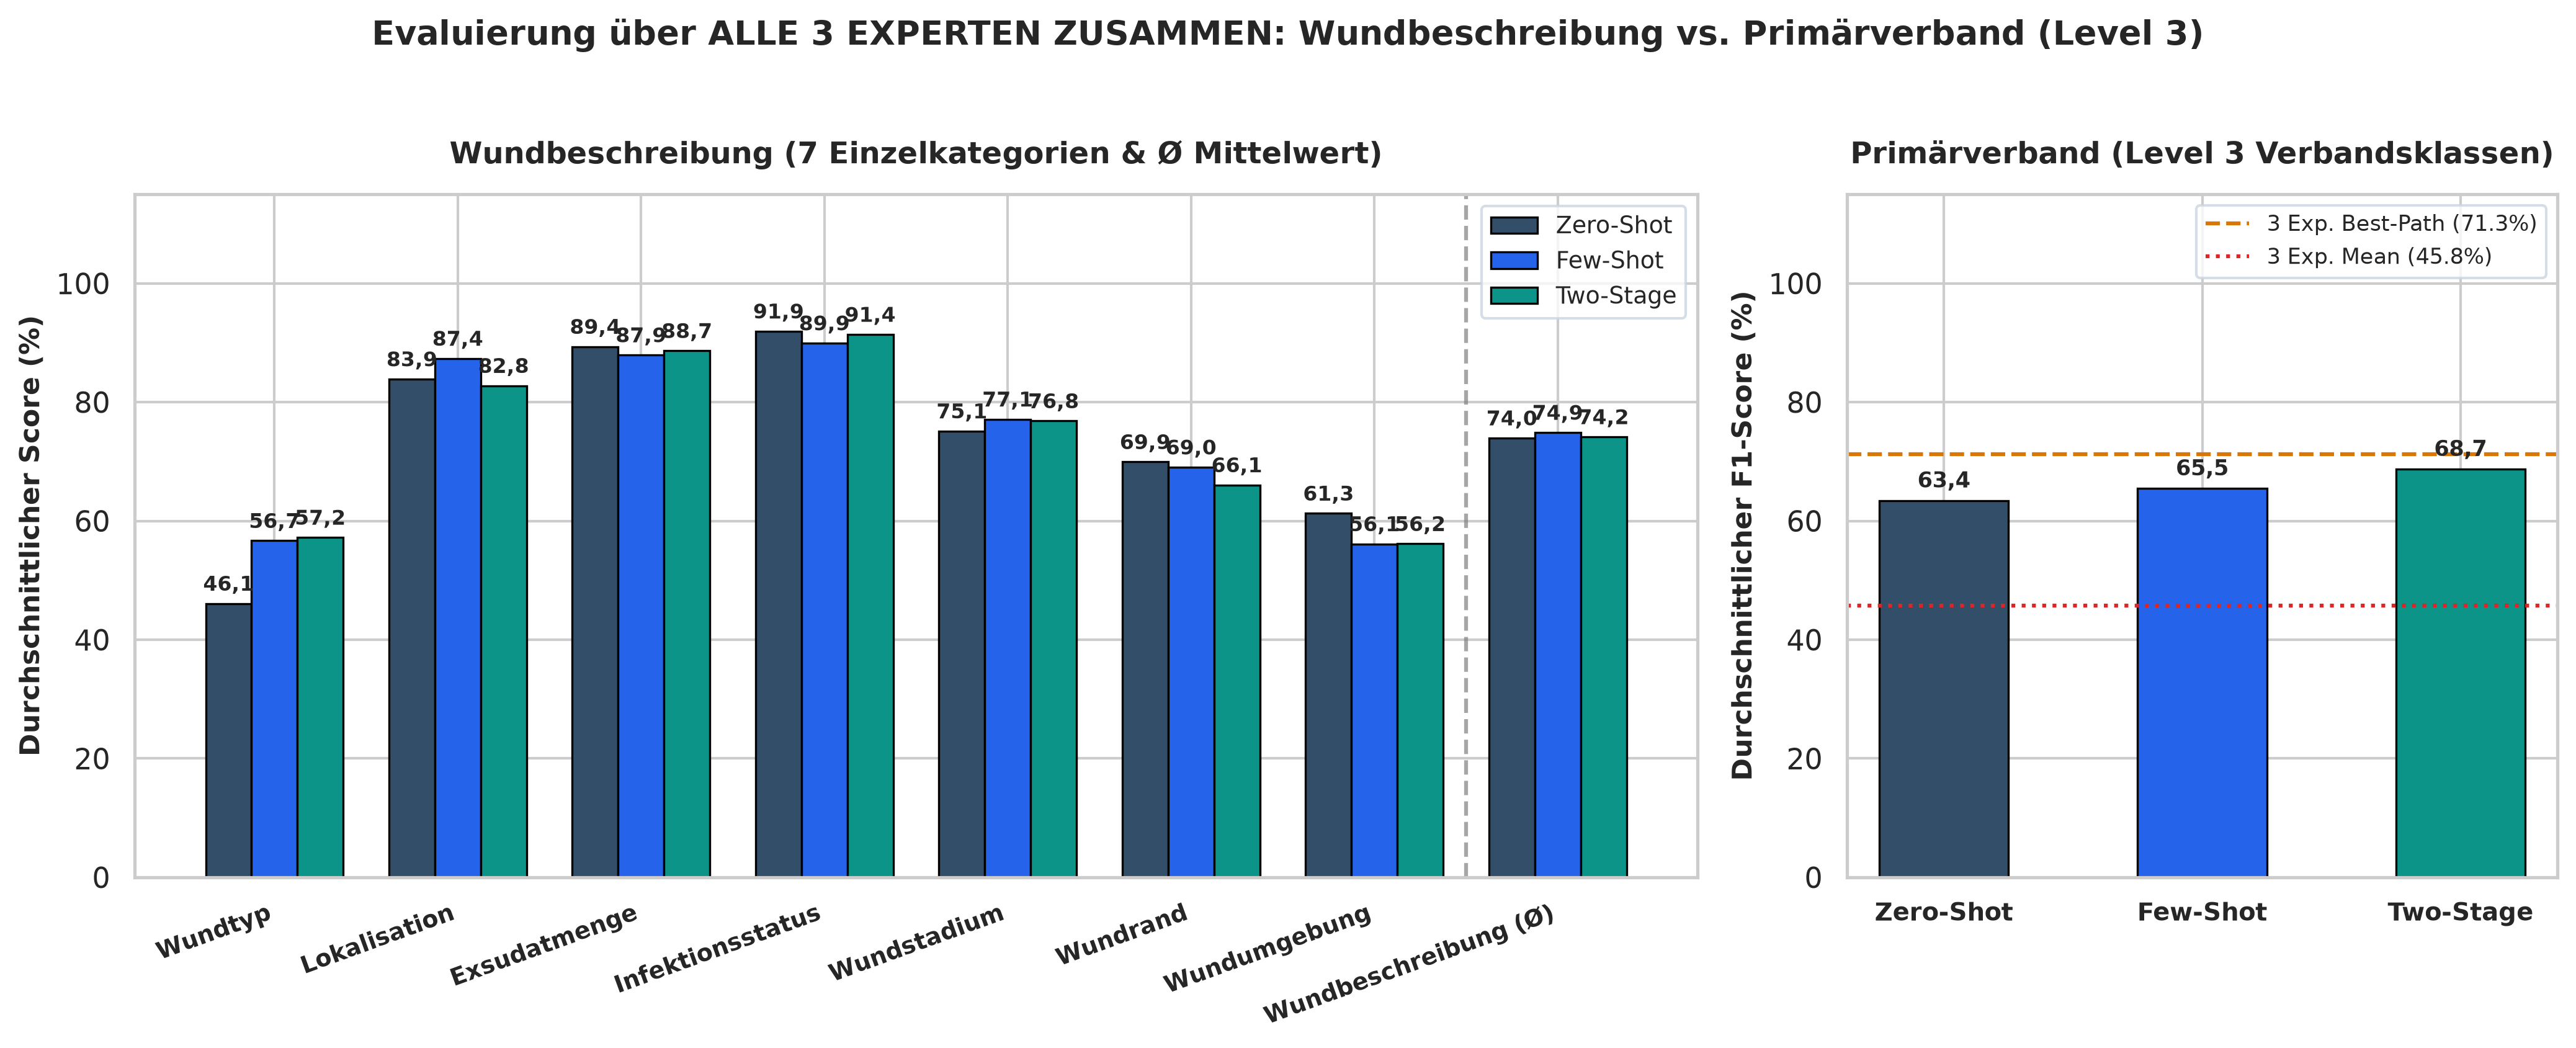

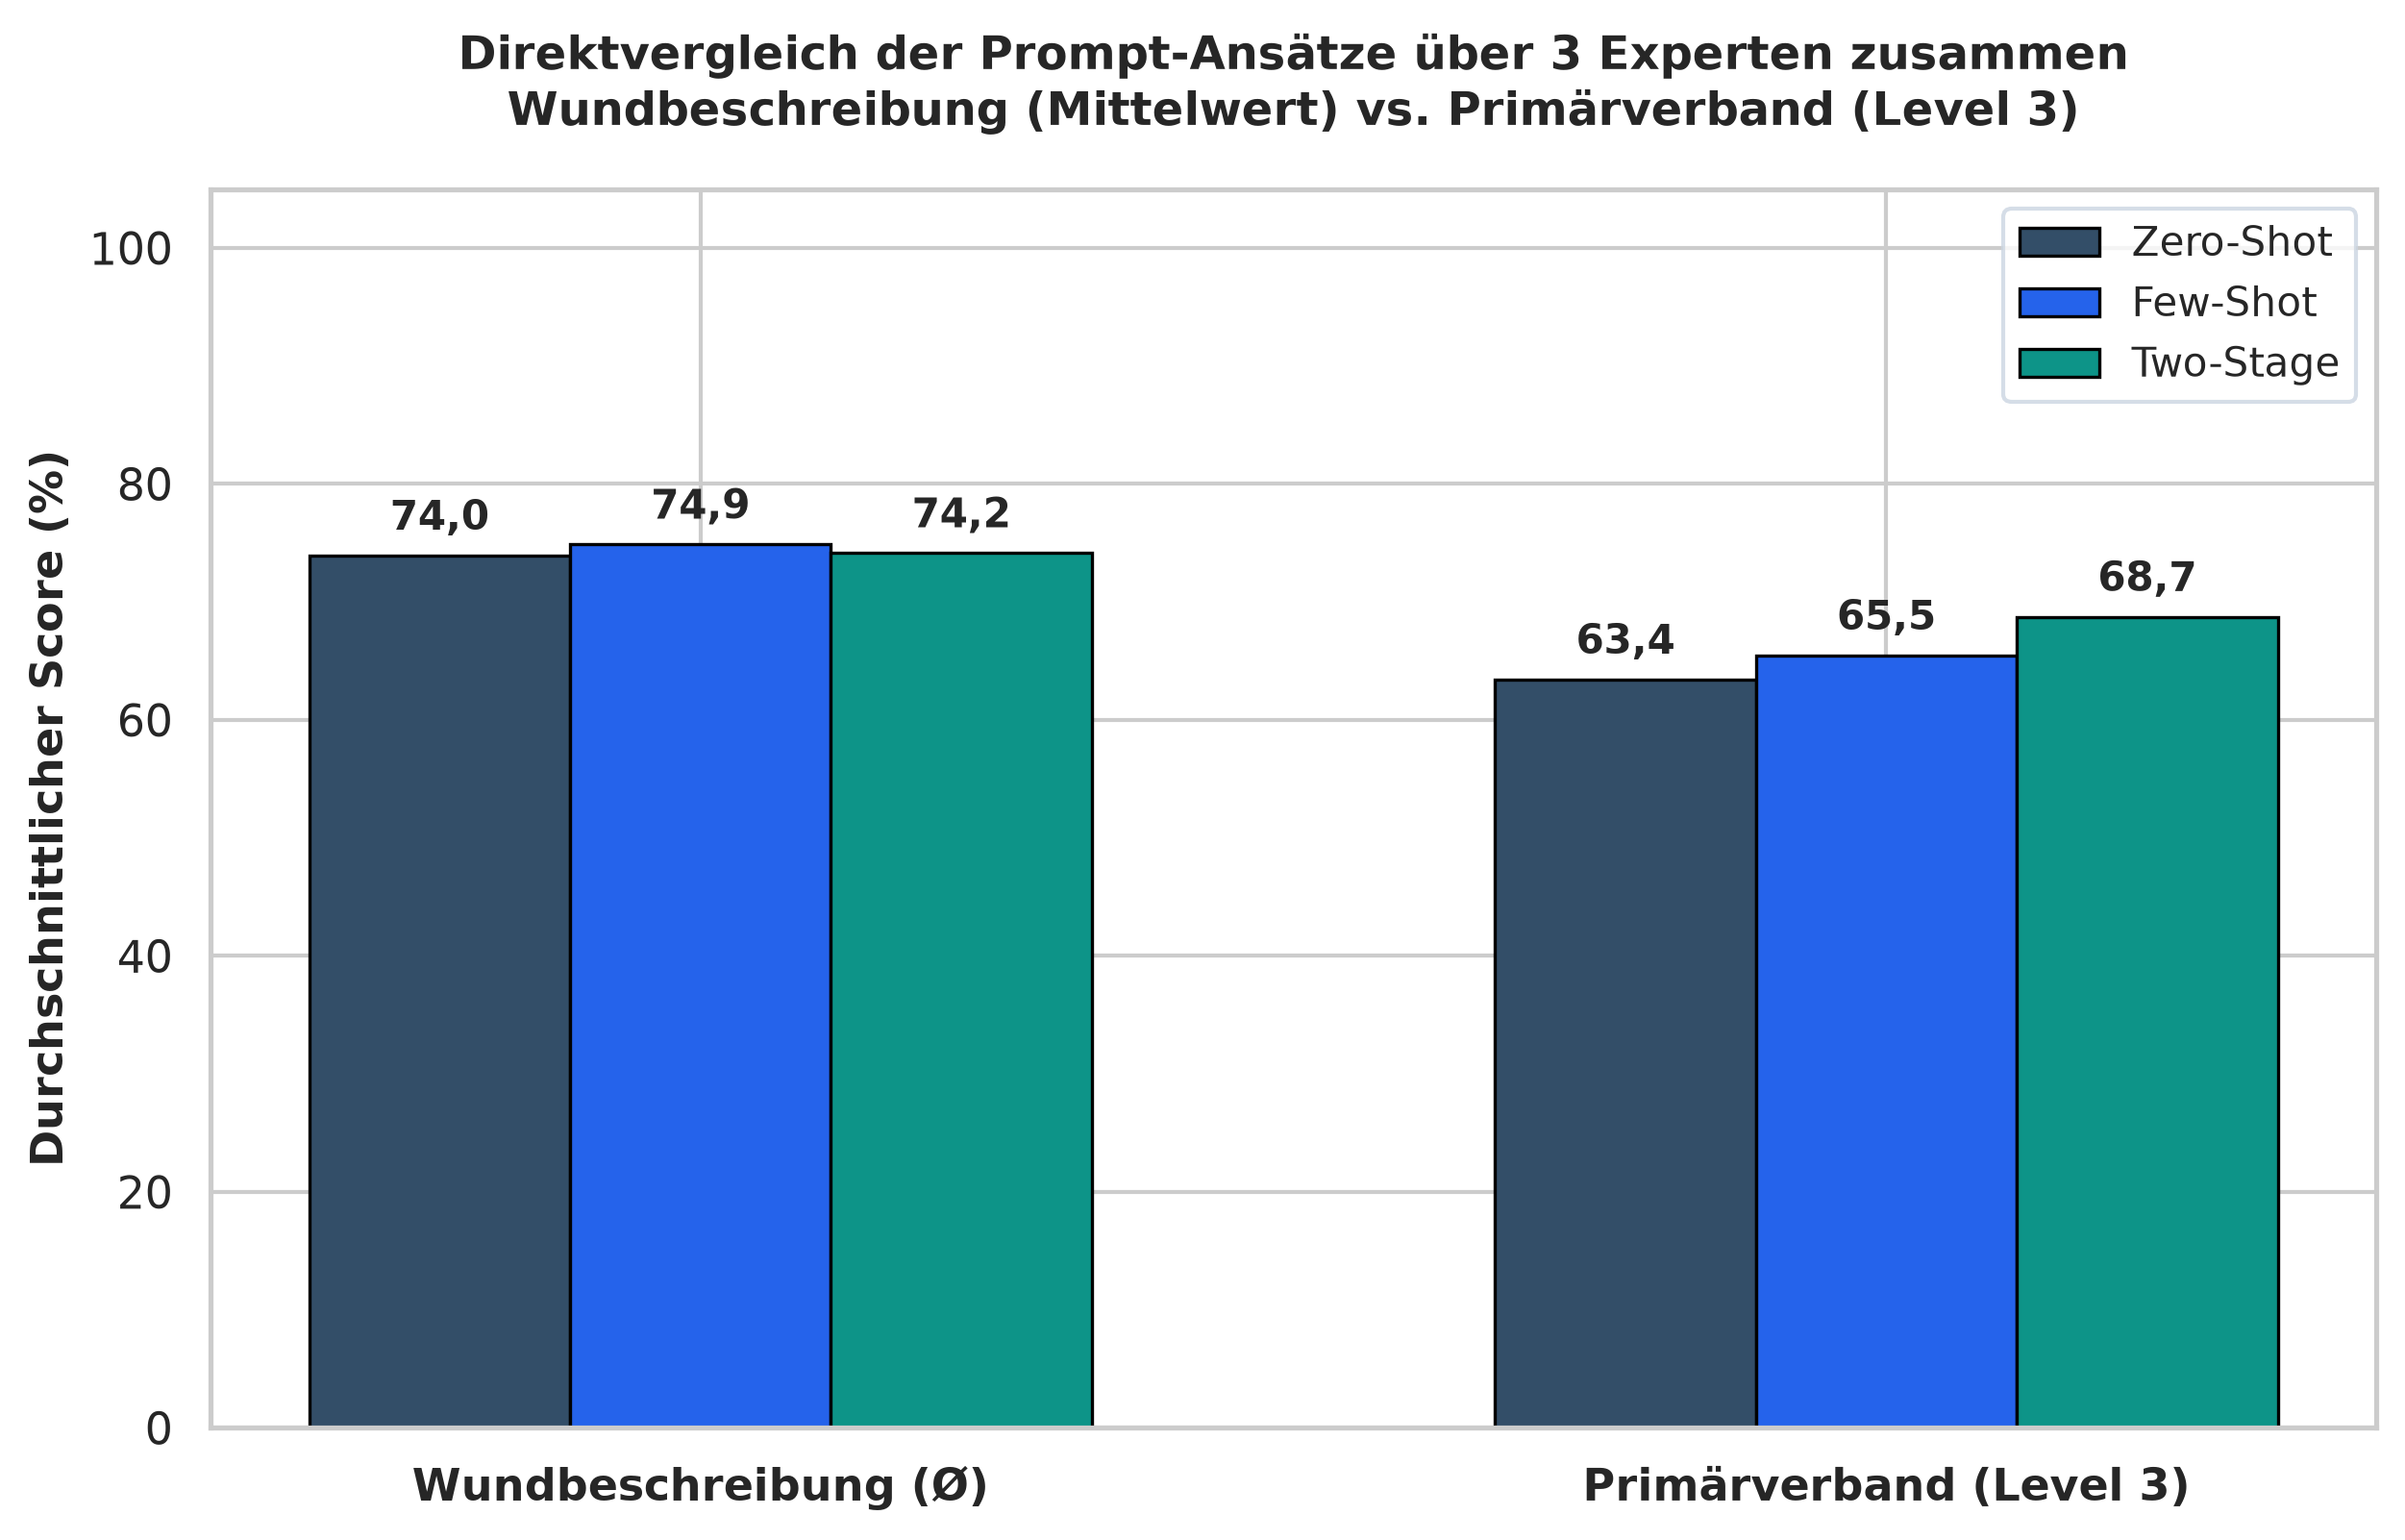

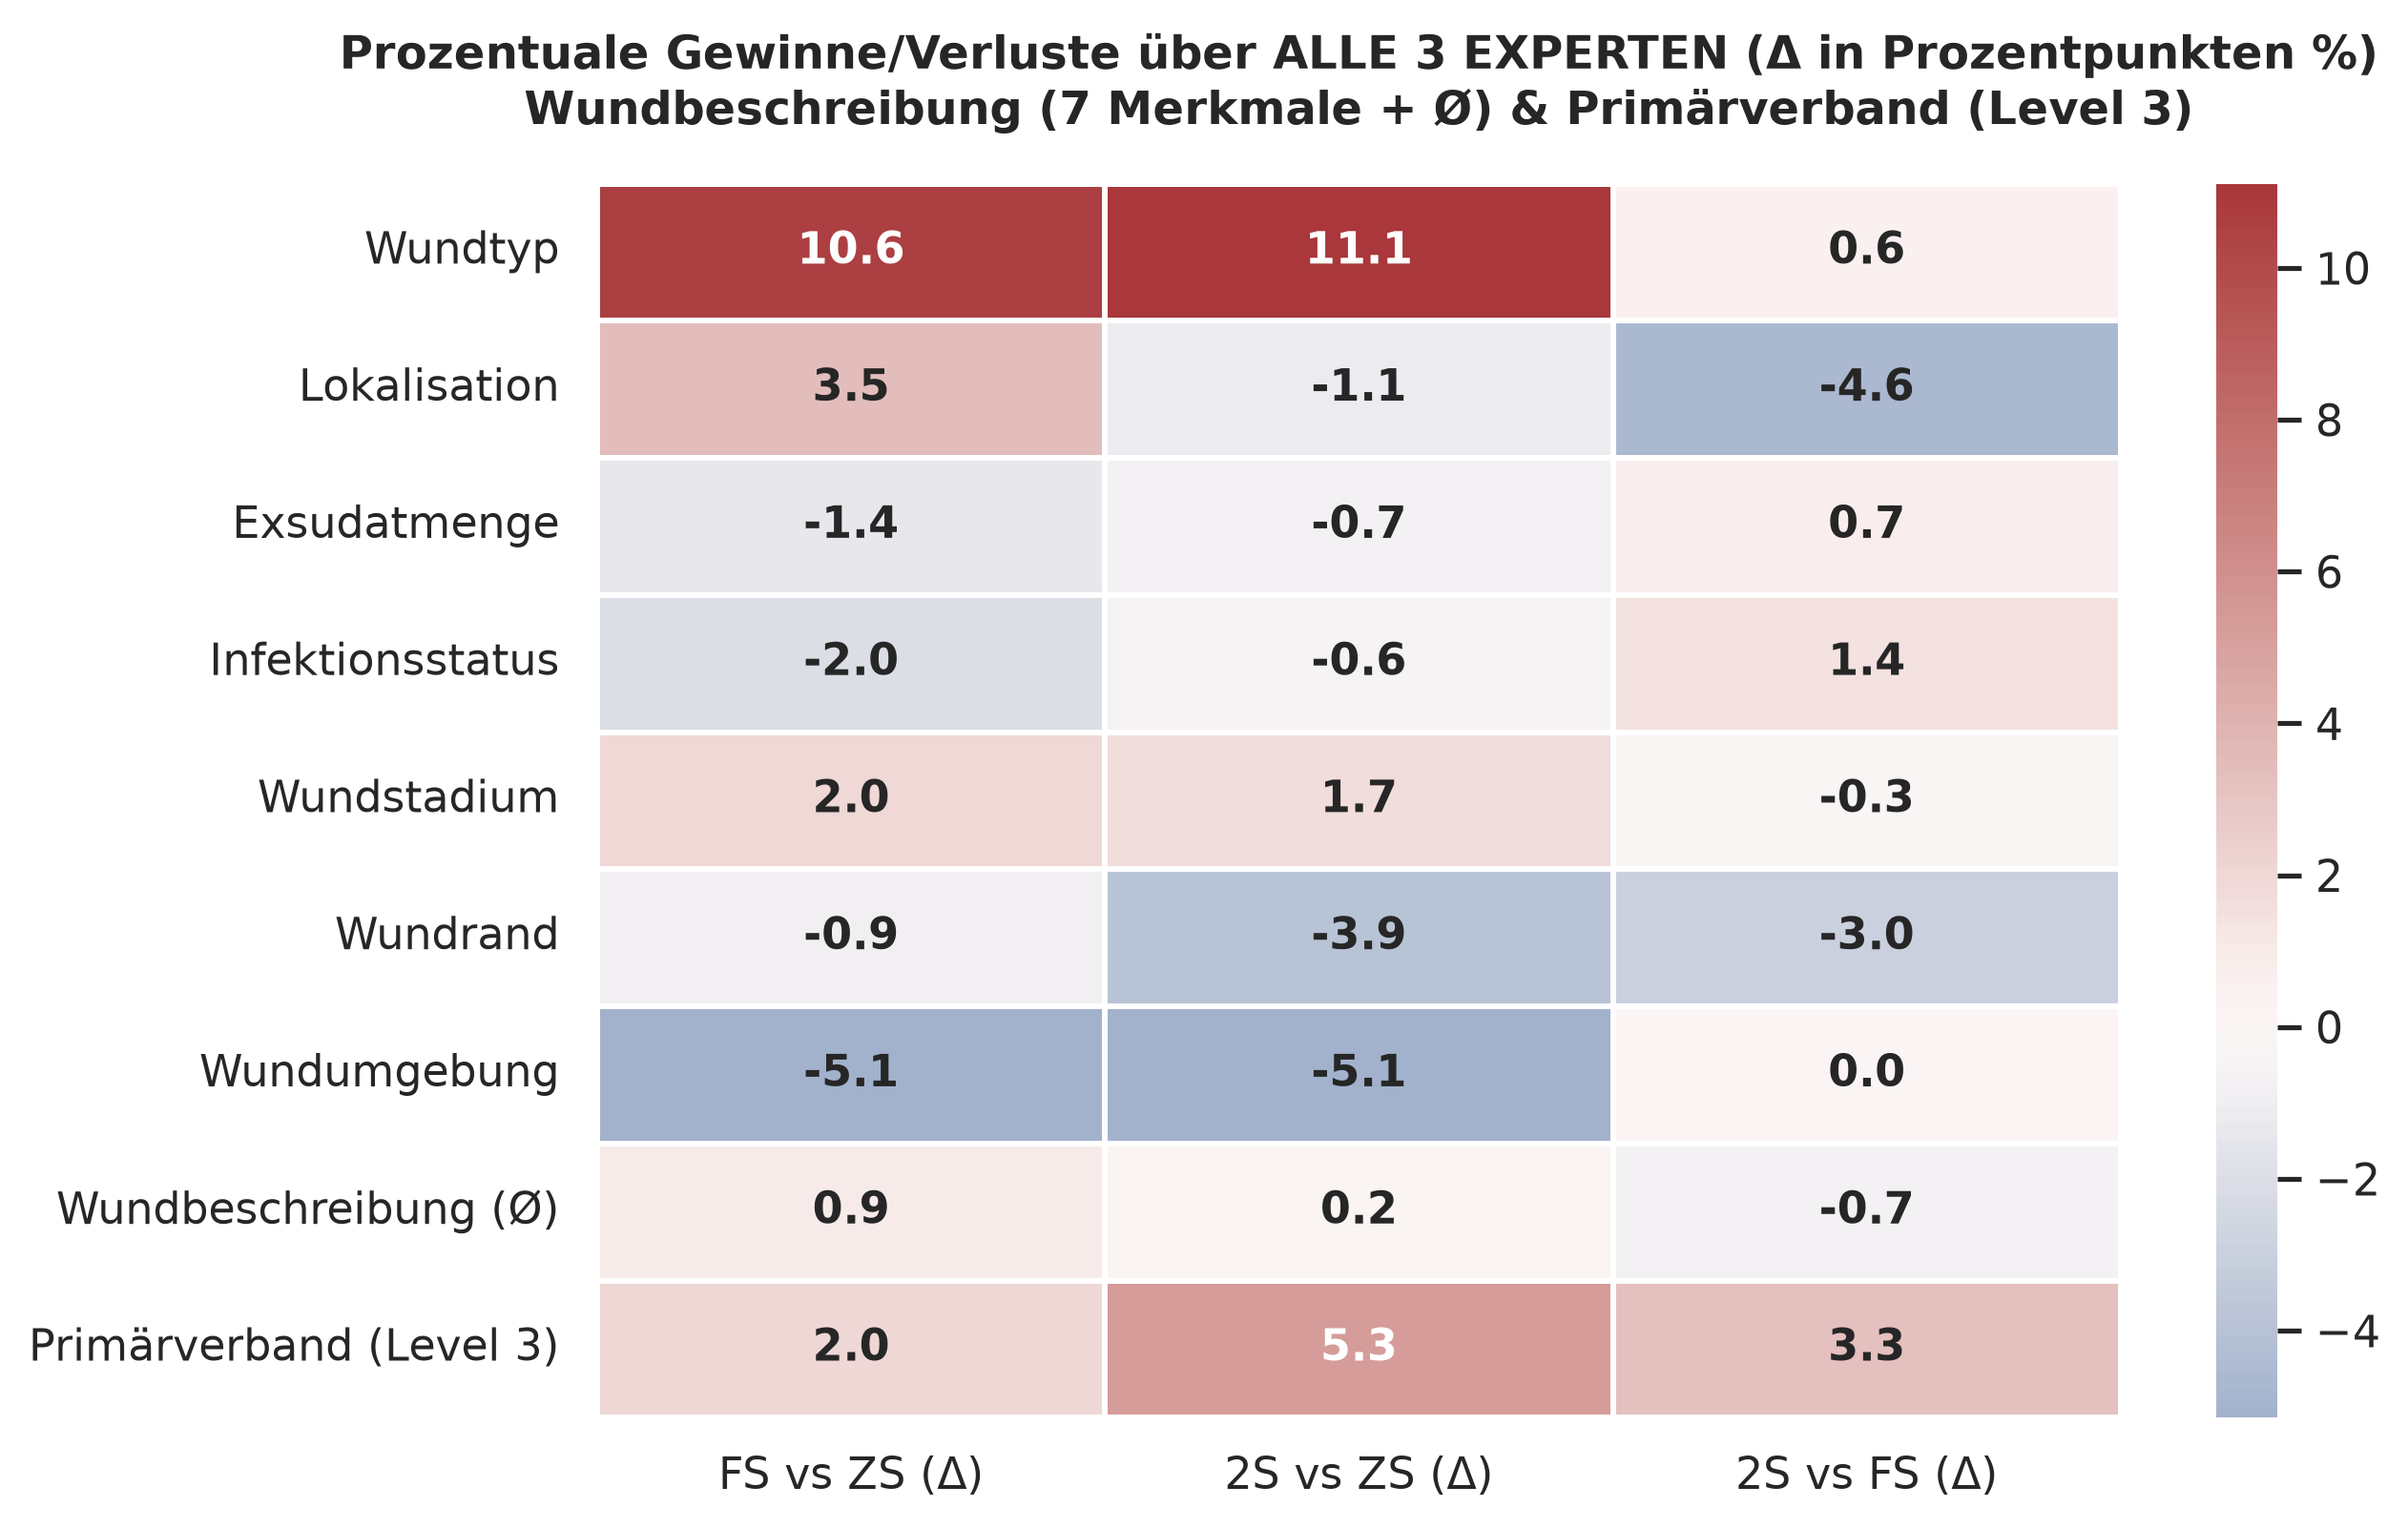

In [5]:
# Berechne 3-Experten gewichtete Durchschnitte (2/3 L&R + 1/3 NursIT)
df_w = df_master.loc[wund_rows, ["lr_ZS", "lr_FS", "lr_2S", "nurs_ZS", "nurs_FS", "nurs_2S"]].copy()
df_w.index = clean_labels

df_3exp = pd.DataFrame()
df_3exp["Zero-Shot"] = (df_w["lr_ZS"] * 2 + df_w["nurs_ZS"]) / 3.0
df_3exp["Few-Shot"] = (df_w["lr_FS"] * 2 + df_w["nurs_FS"]) / 3.0
df_3exp["Two-Stage"] = (df_w["lr_2S"] * 2 + df_w["nurs_2S"]) / 3.0

# Aggregierter Mittelwert Wundbeschreibung über alle 3 Experten
w_mean = df_3exp.mean()
df_3exp.loc["Wundbeschreibung (Ø)"] = w_mean

# Level 3 Primärverband (3 Experten)
lr3 = calculate_primaerverband_lr_scores(level_num=3)
nu3 = calculate_primaerverband_nursit_scores()
best_3exp, mean_3exp = calculate_3_expert_inter_rater_level3()

pv3_lr_zs, pv3_lr_fs, pv3_lr_2s = lr3["right_values"]
pv3_nu_zs, pv3_nu_fs, pv3_nu_2s = nu3["right_values"]

pv3_3exp_zs = (pv3_lr_zs * 2 + pv3_nu_zs) / 3.0
pv3_3exp_fs = (pv3_lr_fs * 2 + pv3_nu_fs) / 3.0
pv3_3exp_2s = (pv3_lr_2s * 2 + pv3_nu_2s) / 3.0

df_3exp.loc["Primärverband (Level 3)"] = [pv3_3exp_zs, pv3_3exp_fs, pv3_3exp_2s]

df_3exp["FS vs ZS (Δ)"] = df_3exp["Few-Shot"] - df_3exp["Zero-Shot"]
df_3exp["2S vs ZS (Δ)"] = df_3exp["Two-Stage"] - df_3exp["Zero-Shot"]
df_3exp["2S vs FS (Δ)"] = df_3exp["Two-Stage"] - df_3exp["Few-Shot"]

print("=== 3 EXPERTEN KONSENS / GESAMTSCHAU (WUNDBESCHREIBUNG & PRIMÄRVERBAND LEVEL 3) ===")
try:
    display(df_3exp.round(1))
except NameError:
    print(df_3exp.round(1))

# 1. PLOT A: Nebeneinander (Gruppierte Wundbeschreibung & Daneben Primärverband Level 3)
sns.set_theme(style="whitegrid", font="sans-serif")
plt.rcParams["font.family"] = "DejaVu Sans"

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5.5), dpi=300, gridspec_kw={"width_ratios": [2.2, 1]})

cat1 = clean_labels + ["Wundbeschreibung (Ø)"]
df_sub1 = df_3exp.loc[cat1].copy()

x1 = np.arange(len(cat1))
w = 0.25

b1_1 = ax1.bar(x1 - w, df_sub1["Zero-Shot"], width=w, label="Zero-Shot", color="#334E68", edgecolor="black", linewidth=0.8)
b1_2 = ax1.bar(x1, df_sub1["Few-Shot"], width=w, label="Few-Shot", color="#2563EB", edgecolor="black", linewidth=0.8)
b1_3 = ax1.bar(x1 + w, df_sub1["Two-Stage"], width=w, label="Two-Stage", color="#0D9488", edgecolor="black", linewidth=0.8)

ax1.axvline(x=6.5, color="gray", linestyle="--", linewidth=1.5, alpha=0.7)
ax1.set_xticks(x1)
ax1.set_xticklabels(cat1, fontweight="bold", fontsize=9, rotation=20, ha="right")
ax1.set_ylabel("Durchschnittlicher Score (%)", fontweight="bold", fontsize=10.5)
ax1.set_ylim(0, 115)
ax1.set_title("Wundbeschreibung (7 Einzelkategorien & Ø Mittelwert)", fontweight="bold", fontsize=11.5, pad=12)
ax1.legend(loc="upper right", frameon=True, facecolor="#FFFFFF", edgecolor="#CBD5E1", fontsize=9)

for bar in list(b1_1) + list(b1_2) + list(b1_3):
    val = bar.get_height()
    if val > 0:
        ax1.annotate(f"{val:.1f}".replace(".", ","), xy=(bar.get_x() + bar.get_width()/2, val), xytext=(0, 3),
                    textcoords="offset points", ha="center", va="bottom", fontsize=8, fontweight="bold")

# Subplot 2: Primärverband (Level 3)
cat2 = ["Zero-Shot", "Few-Shot", "Two-Stage"]
vals2 = [pv3_3exp_zs, pv3_3exp_fs, pv3_3exp_2s]
colors2 = ["#334E68", "#2563EB", "#0D9488"]
x2 = np.arange(len(cat2))

b2 = ax2.bar(x2, vals2, color=colors2, width=0.5, edgecolor="black", linewidth=0.8)
ax2.axhline(y=best_3exp, color="#D97706", linestyle="--", linewidth=1.5, label=f"3 Exp. Best-Path ({best_3exp:.1f}%)")
ax2.axhline(y=mean_3exp, color="#DC2626", linestyle=":", linewidth=1.5, label=f"3 Exp. Mean ({mean_3exp:.1f}%)")

ax2.set_xticks(x2)
ax2.set_xticklabels(cat2, fontweight="bold", fontsize=9.5)
ax2.set_ylabel("Durchschnittlicher F1-Score (%)", fontweight="bold", fontsize=10.5)
ax2.set_ylim(0, 115)
ax2.set_title("Primärverband (Level 3 Verbandsklassen)", fontweight="bold", fontsize=11.5, pad=12)
ax2.legend(loc="upper right", frameon=True, facecolor="#FFFFFF", edgecolor="#CBD5E1", fontsize=8.5)

for bar in b2:
    val = bar.get_height()
    ax2.annotate(f"{val:.1f}".replace(".", ","), xy=(bar.get_x() + bar.get_width()/2, val), xytext=(0, 3),
                textcoords="offset points", ha="center", va="bottom", fontsize=8.5, fontweight="bold")

plt.suptitle("Evaluierung über ALLE 3 EXPERTEN ZUSAMMEN: Wundbeschreibung vs. Primärverband (Level 3)", fontweight="bold", fontsize=13, y=1.02)
plt.tight_layout()
plt.savefig("../../exports/pngs/prompt_ansatze_wundbeschreibung_daneben_primaerverband_l3.png", dpi=300, bbox_inches="tight")
plt.show()

# 2. PLOT B: Kompakter Direktvergleich (Gruppierter Wundbeschreibung-Mittelwert & Primärverband Level 3)
df_grouped = df_3exp.loc[["Wundbeschreibung (Ø)", "Primärverband (Level 3)"], ["Zero-Shot", "Few-Shot", "Two-Stage"]].copy()

fig, ax = plt.subplots(figsize=(8.5, 5.5), dpi=300)
x_g = np.arange(len(df_grouped.index))
w_g = 0.22

bg1 = ax.bar(x_g - w_g, df_grouped["Zero-Shot"], width=w_g, label="Zero-Shot", color="#334E68", edgecolor="black", linewidth=0.8)
bg2 = ax.bar(x_g, df_grouped["Few-Shot"], width=w_g, label="Few-Shot", color="#2563EB", edgecolor="black", linewidth=0.8)
bg3 = ax.bar(x_g + w_g, df_grouped["Two-Stage"], width=w_g, label="Two-Stage", color="#0D9488", edgecolor="black", linewidth=0.8)

ax.set_xticks(x_g)
ax.set_xticklabels(df_grouped.index, fontweight="bold", fontsize=11)
ax.set_ylabel("Durchschnittlicher Score (%)", fontweight="bold", fontsize=11)
ax.set_ylim(0, 105)
ax.set_title("Direktvergleich der Prompt-Ansätze über 3 Experten zusammen\nWundbeschreibung (Mittelwert) vs. Primärverband (Level 3)", fontweight="bold", fontsize=11.5, pad=16)
ax.legend(loc="upper right", frameon=True, facecolor="#FFFFFF", edgecolor="#CBD5E1", fontsize=10)

for bar in list(bg1) + list(bg2) + list(bg3):
    val = bar.get_height()
    ax.annotate(f"{val:.1f}".replace(".", ","), xy=(bar.get_x() + bar.get_width()/2, val), xytext=(0, 4),
                textcoords="offset points", ha="center", va="bottom", fontsize=10, fontweight="bold")

plt.tight_layout()
plt.savefig("../../exports/pngs/prompt_ansatze_wundbeschreibung_vs_primaerverband_kompakt.png", dpi=300, bbox_inches="tight")
plt.show()

# 3. Heatmap der Deltas über alle 3 Experten zusammen
df_delta_3exp = df_3exp[["FS vs ZS (Δ)", "2S vs ZS (Δ)", "2S vs FS (Δ)"]].copy()
fig, ax = plt.subplots(figsize=(9, 5.5), dpi=300)
sns.heatmap(df_delta_3exp, annot=True, fmt=".1f", cmap="vlag", center=0, cbar=True, ax=ax, linewidths=1.0, annot_kws={"fontweight": "bold", "fontsize": 11})
ax.set_title("Prozentuale Gewinne/Verluste über ALLE 3 EXPERTEN (Δ in Prozentpunkten %)\nWundbeschreibung (7 Merkmale + Ø) & Primärverband (Level 3)", fontweight="bold", fontsize=11.5, pad=15)
plt.tight_layout()
plt.savefig("../../exports/pngs/prompt_ansatze_3_experten_delta_heatmap.png", dpi=300, bbox_inches="tight")
plt.show()

## 5. Zusammenfassung & Erkenntnisse für die Masterarbeit

### Key Takeaways Lohmann & Rauscher (2 Experten Konsens):
1. **Wundbeschreibung (Ø ~76–78%):**
   - **Few-Shot** erzielt mit **77,8%** das beste Ergebnis (+1,5% ggü. Zero-Shot).
   - **Two-Stage** bringt bei der reinen Merkmalsbeschreibung keinen zusätzlichen Gewinn (76,6%).

2. **Primärverband (Level 2) — Gewinner: Two-Stage (+8,3%):**
   - **Two-Stage** dominiert mit **70,4%** (Zero-Shot: 62,1%, Few-Shot: 64,7%).
   - *Grund:* Die stufenweise Entkopplung (zuerst Beschreibung, dann begründete Produktwahl) ermöglicht der KI eine deutlich präzisere Zuordnung zu Produktfamilien.

3. **Debridement Methode — Gewinner: Two-Stage (+5,5%):**
   - **Two-Stage** erreicht **57,6%** (Zero-Shot: 52,1%, Few-Shot: 53,4%).
   - *Grund:* Auch bei der Indikation von Debridement-Verfahren stärkt der strukturierte Zwischenschritt die Logik.

4. **Sekundärverband — Gewinner: Few-Shot (+16,7%):**
   - **Few-Shot** springt auf **23,3%** (Zero-Shot: 6,7%, Two-Stage: 5,0%).
   - *Grund:* Bei freien Freitext-Checklisten mit vielen Produktbezeichnungen benötigt die KI konkrete In-Context-Beispiele, um das Syntaxformat korrekt zu treffen.

---

### Key Takeaways NursIT (Experte 3):
1. **Wundbeschreibung (Ø ~69%):**
   - Nahezu identisches Leistungsniveau über alle drei Ansätze (**Zero-Shot: 69,3%**, **Few-Shot: 69,1%**, **Two-Stage: 69,2%**).
   - *Detail-Unterschiede:* `Wundtyp` profitiert stark von **Two-Stage** (+3,3% vs ZS, +5,0% vs FS), während `Lokalisation` und `Wundrand` im Zero-Shot leicht am besten abschneiden.

2. **Debridement Methode — Gewinner: Two-Stage (+5,2% vs ZS, +8,2% vs FS):**
   - **Two-Stage** steigt von **58,3% (Zero-Shot)** und **55,4% (Few-Shot)** auf **63,6%**.
   - *Erkenntnis:* Wie bei L&R führt die zweistufige Prozess-Entkopplung auch beim NursIT Experten zu einer signifikanten Leistungssteigerung.

3. **Kompressionsindikation & Kompressionsprodukte:**
   - **Kompressionsindikation:** **Two-Stage (61,7%)** und **Few-Shot (55,2%)** übertreffen **Zero-Shot (31,7%)** massiv (+30,0% bzw. +23,5%).
   - **Kompressionsprodukte:** **Few-Shot** erreicht **12,8%** (Zero-Shot: 0,0%, Two-Stage: 2,1%). In-Context-Beispiele sind zwingend erforderlich, um Produktbezeichnungen aus dem freien Freitext zu extrahieren.

---

### Key Takeaways über ALLE 3 EXPERTEN ZUSAMMEN (Wundbeschreibung & Primärverband Level 3):
1. **Wundbeschreibung Gesamtmittelwert (Ø ~74–75%):**
   - **Few-Shot** schneidet mit **74,9%** am besten ab, knapp vor **Two-Stage (74,2%)** und **Zero-Shot (74,0%)**.
   - **Wundtyp-Klassifikation** zeigt den größten Gewinn durch strukturierte Prompts: **Two-Stage (+11,1%)** und **Few-Shot (+10,6%)** übertreffen Zero-Shot (46,1%) deutlich.
   - **Lokalisation** erreicht mit **Few-Shot (87,4%)** den Höchstwert (+3,5% vs. ZS).

2. **Primärverband (Level 3 — Verbandsklassen-Ebene):**
   - **Two-Stage** ist der deutliche Gewinner mit **68,7%** (Zero-Shot: 63,4%, Few-Shot: 65,5%).
   - Das Two-Stage Modell nähert sich damit sehr stark der **3-Experten Best-Path Inter-Rater Reliabilität (71,3%)** an und liegt weit über der durchschnittlichen Experten-Einigkeit (**45,8%**).
   - *Fazit:* Bei der Zuordnung zu übergreifenden Verbandsklassen (z.B. Alginate, Hydrofaser, Schaumstoffe) liefert die zweistufige Argumentationskette die präzisesten klinischen Entscheidungen.